# OVERVIEW

This notebook acts as an example of how to use associated /src .py files

### Imports

In [1]:
import hashlib
import sys
from pathlib import Path
import pandas as pd
if not globals().get("_TRADING_PORTFOLIO_PATHS_READY"):
    _HERE = (Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve())
    _PROJECTS = (
        "past_market_analysis",
        "technical_analysis",
        "options_pricing",
        "time_series_forecasting",
        "portfolio_construction",
        "ml_fundamentals",
        "ml_trading_signals",
        "risk_management",
        "reversal_signals",
        "trading_bot"
    )
    _REPO_ROOT = next((directory for directory in (_HERE, *_HERE.parents) if (directory / "reversal_signals" / "src").is_dir()), None)
    if _REPO_ROOT is None:
        raise RuntimeError("Could not locate the reversal_signals project.")
    _PORTFOLIO_ROOT = next(directory for directory in (_REPO_ROOT, *_REPO_ROOT.parents) if (directory / "original_portfolio").is_dir())
    _SRC_PATHS = [str(path.resolve()) for project in _PROJECTS for path in _PORTFOLIO_ROOT.glob(f"*/{project}/src")]
    if str(_PORTFOLIO_ROOT.parent) not in sys.path:
        sys.path.append(str(_PORTFOLIO_ROOT.parent))
    import trading_portfolio
    if str(_REPO_ROOT) not in list(trading_portfolio.__path__):
        #a plain list survives sys.path changes; a namespace path is recalculated and would drop this
        trading_portfolio.__path__ = [*trading_portfolio.__path__, str(_REPO_ROOT)]
    sys.path.extend(path for path in _SRC_PATHS if path not in sys.path)
    _TRADING_PORTFOLIO_PATHS_READY = True

import pandas as pd
import pandas_market_calendars as mcal
import numpy as np

import reversal_data
import reversal_features
import reversal_validation


DATA_SOURCE = "yfinance"
MARKET_CALENDAR = "LSE"

universe_path = (_PORTFOLIO_ROOT.parent / "t212_universe" / "t212_reversal_candidates.csv")
catalogue = pd.read_csv(universe_path, dtype=str, keep_default_na=False)

candidate_pool = catalogue.loc[catalogue["instrument_type"].eq("ordinary_share")
    & catalogue["quote_unit"].isin(["GBP", "GBX"])
    & catalogue["exchange"].isin(["London Stock Exchange", "London Stock Exchange AIM"]) 
    & catalogue["review_flags"].eq("")].copy()



/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Now fix the research periods and baselines:

In [2]:
UK_PERIODS = {
    "development_start": "2015-01-01",
    "development_end_exclusive": "2022-01-01",
    "holdout_start": "2022-01-01",
    "holdout_end_exclusive": "2024-01-01",
}

UK_BASELINE = {
    "formation_sessions": 5,
    "top_frac": 0.20,
    "holding_sessions": 5,
    "rebalance_sessions": 5,
    "min_eligible": 10,
    "initial_capital_gbp": 10_000
}

In [3]:
display(pd.Series(UK_PERIODS, name="date"))
display(pd.Series(UK_BASELINE, name="setting"))

development_start            2015-01-01
development_end_exclusive    2022-01-01
holdout_start                2022-01-01
holdout_end_exclusive        2024-01-01
Name: date, dtype: object

formation_sessions         5.0
top_frac                   0.2
holding_sessions           5.0
rebalance_sessions         5.0
min_eligible              10.0
initial_capital_gbp    10000.0
Name: setting, dtype: float64

## **Data Prep**

In [4]:
print("Catalogue rows:", len(catalogue))
print("Provisional candidates:", len(candidate_pool))
display(candidate_pool.groupby("exchange").size().rename("candidates").to_frame())

Catalogue rows: 669
Provisional candidates: 646


,candidates
exchange,
London Stock Exchange,41
London Stock Exchange AIM,605


The starting available universe is all of the tickers above, so 646. We start by defining some eligibility conditions, and then imposing them.

In [5]:
UK_ELIGIBILITY = {
    "liquidity_lookback_sessions": 60, #complete price, volume obs for 60 days before signal date
    "min_median_traded_value_gbp": 100_000, #at least 100000(gbp) of median trading volume daily
    "max_zero_volume_fraction": 0.05, #no more than 3/60 zero obs days
    "require_complete_formation_window": True, #valid and positive adjusted closes throughout 5 session window (6 closing prices including signal day)
    "require_positive_signal_day_volume": True #positive reported volume
}

display(pd.Series(UK_ELIGIBILITY, name="setting"))

liquidity_lookback_sessions               60
min_median_traded_value_gbp           100000
max_zero_volume_fraction                0.05
require_complete_formation_window       True
require_positive_signal_day_volume      True
Name: setting, dtype: object

In [6]:
cache_dir = (_REPO_ROOT / "reversal_signals" / "data" / "uk_2015_2021_v1")

uk_raw_panel = pd.read_pickle(cache_dir / "raw_panel_v1.pkl")
uk_tickers = sorted(candidate_pool["yf_symbol"].tolist())
cached_tickers = sorted(uk_raw_panel["ticker"].unique().tolist())
missing_tickers = sorted(set(uk_tickers) - set(cached_tickers))

print("Candidates:", len(uk_tickers))
print("With cached prices:", len(cached_tickers))
print("Without cached prices:", len(missing_tickers))



Candidates: 646
With cached prices: 528
Without cached prices: 118


We reduce to this selection of 528 tickers for data availability reasons.

In [7]:
uk_schedule = mcal.get_calendar(MARKET_CALENDAR).schedule(start_date=UK_PERIODS["development_start"],
end_date=(pd.Timestamp(UK_PERIODS["development_end_exclusive"]) - pd.Timedelta(days=1)))

uk_schedule.index.name = "Date"
uk_coverage = reversal_data.audit_price_coverage(uk_raw_panel, uk_tickers, uk_schedule.index)
print("LSE sessions:", len(uk_schedule))

display(uk_coverage[["duplicate_extra_rows", "unexpected_dates", "incomplete_rows"]].sum().to_frame("total"))
display(uk_coverage.head(10))

LSE sessions: 1771


,total
duplicate_extra_rows,0
unexpected_dates,0
incomplete_rows,8


,rows_returned,expected_sessions,duplicate_extra_rows,missing_sessions,unexpected_dates,incomplete_rows
ticker,,,,,,
450.L,0,1771,0,1771,0,0
4BB.L,221,1771,0,1550,0,0
4GBL.L,0,1771,0,1771,0,0
80M.L,1771,1771,0,0,0,0
88E.L,1771,1771,0,0,0,0
AAU.L,1771,1771,0,0,0,0
AAZ.L,1771,1771,0,0,0,0
ABDP.L,1771,1771,0,0,0,0
ABDX.L,264,1771,0,1507,0,0


In [8]:
uk_panel = reversal_data.align_price_panel(uk_raw_panel, cached_tickers, uk_schedule.index)

print("Aligned rows:", len(uk_panel))
print("Observed rows:", int(uk_panel["observed_row"].sum()))
print("Inserted missing rows:", int((~uk_panel["observed_row"]).sum()))
display(uk_panel.head())

Aligned rows: 935088
Observed rows: 764391
Inserted missing rows: 170697


,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume,ticker,observed_row
Date,,,,,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4BB.L,False
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WISE.L,False
2015-01-02,75.914749,76.0,0.0,76.0,76.0,76.0,0.0,44368.0,IGR.L,True
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BKS.L,False
2015-01-02,191.193039,192.5,0.0,192.5,192.5,192.5,0.0,0.0,CMCL.L,True


There are various scaling issues within the dataset used, for example various scaling issues of GBP (pounds) to GBp (pence). This is fixed below.

In [9]:
price_columns = ["Open", "High", "Low", "Close", "Adj Close"]
unit_corrections = pd.read_csv(cache_dir / "proposed_unit_corrections.csv", parse_dates=["Date"])

#start from unchanged aligned panel on each run
uk_unit_panel = uk_panel.copy()
uk_unit_panel["unit_correction_provisional"] = False

for correction in unit_corrections.itertuples(index=False):
    mask = (uk_unit_panel["ticker"].eq(correction.ticker) & (uk_unit_panel.index == correction.Date))
    if mask.sum() != 1:
        raise ValueError(f"Expected one row for {correction.ticker}.")

    original_close = uk_unit_panel.loc[mask, "Close"].iloc[0]
    if not np.isclose(original_close, correction.expected_original_close):
        raise ValueError(
            f"Unexpected original price for {correction.ticker} on {correction.Date.date()}.")
    uk_unit_panel.loc[mask, price_columns] *= correction.price_multiplier
    uk_unit_panel.loc[mask, "unit_correction_provisional"] = True

display(uk_unit_panel.loc[uk_unit_panel["unit_correction_provisional"], ["ticker", "Close", "Adj Close"]])

,ticker,Close,Adj Close
Date,,,
2021-02-03,SUP.L,155.0,154.736104
2021-02-05,SUP.L,178.0,177.696973
2021-02-08,SUP.L,184.0,183.686699
2021-03-23,COIL.L,82.5,82.500000
2021-03-29,AOM.L,186.5,186.500000
2021-04-06,FIN.L,61.5,61.500000


In [10]:

split_corrections = pd.read_csv(cache_dir / "proposed_split_corrections.csv", parse_dates=["Date"])

# ROAD also needs its listing gap handled separately.
simple_splits = split_corrections.loc[split_corrections["ticker"].isin(["BCE.L", "PXEN.L"])]

uk_split_panel = uk_unit_panel.copy()
uk_split_panel["split_correction_provisional"] = False
for correction in simple_splits.itertuples(index=False):
    ticker_mask = uk_split_panel["ticker"].eq(correction.ticker)
    event_mask = ticker_mask & (uk_split_panel.index == correction.Date)

    if event_mask.sum() != 1:
        raise ValueError(f"Expected one event row for {correction.ticker}.")

    if correction.scope == "event_row":
        affected = event_mask
        uk_split_panel.loc[affected, price_columns] *= correction.factor
    elif correction.scope == "earlier_history":
        affected = ticker_mask & (uk_split_panel.index < correction.Date)

        uk_split_panel.loc[affected, price_columns + ["Dividends"]] *= correction.factor
        uk_split_panel.loc[affected, "Volume"] /= correction.factor
    else:
        raise ValueError(f"Unknown correction scope: {correction.scope}")

    uk_split_panel.loc[event_mask, "Stock Splits"] = 1 / correction.factor
    uk_split_panel.loc[affected | event_mask, "split_correction_provisional"] = True

event_rows = [(row.Date, row.ticker) for row in simple_splits.itertuples(index=False)]
display(uk_split_panel.set_index("ticker", append=True).loc[event_rows, ["Close", "Volume", "Stock Splits"]])

,,Close,Volume,Stock Splits
Date,ticker,,,
2018-08-10,BCE.L,10.5,0.0,0.02
2020-07-01,PXEN.L,2.0,0.0,0.04


In [11]:
uk_clean_panel = uk_split_panel.copy()

road = uk_clean_panel["ticker"].eq("ROAD.L")
dates = uk_clean_panel.index
road_split_date = pd.Timestamp("2018-06-25")

before_split = road & (dates < road_split_date)
split_day = road & (dates == road_split_date)

if split_day.sum() != 1:
    raise ValueError("Expected one ROAD consolidation row.")

# Put earlier observations on the post-consolidation share basis.
uk_clean_panel.loc[before_split, price_columns + ["Dividends"]] *= 33
uk_clean_panel.loc[before_split, "Volume"] /= 33
uk_clean_panel.loc[split_day, "Stock Splits"] = 1 / 33
uk_clean_panel.loc[before_split | split_day, "split_correction_provisional"] = True

# Distinguish the unlisted period from trading on another venue.
road_unlisted = (road & (dates >= pd.Timestamp("2018-01-22")) & (dates < pd.Timestamp("2018-06-26")))
road_nex = (road & (dates >= pd.Timestamp("2018-06-26")) & (dates < pd.Timestamp("2020-01-07")))

uk_clean_panel["known_unlisted"] = road_unlisted
uk_clean_panel["known_nex_listing"] = road_nex

# Exclude these dates from the LSE/AIM analysis without deleting rows.
uk_clean_panel.loc[road_unlisted | road_nex, price_columns + ["Volume"]] = np.nan

display(uk_clean_panel[["known_unlisted", "known_nex_listing"]].sum().to_frame("ROAD sessions excluded"))

,ROAD sessions excluded
known_unlisted,107
known_nex_listing,388


Now adjust closing prices.

In [12]:
uk_prices = reversal_data.add_adjusted_prices(uk_clean_panel)

display(uk_prices.loc[uk_prices["Close"].notna(),["ticker",
            "Open",
            "adj_open",
            "Close",
            "adj_close",
            "adjustment_factor"] ].head(10))

,ticker,Open,adj_open,Close,adj_close,adjustment_factor
Date,,,,,,
2015-01-02,IGR.L,76.00000,75.914749,76.000000,75.914749,0.998878
2015-01-02,CMCL.L,192.50000,191.193039,192.500000,191.193039,0.993211
2015-01-02,SAL.L,455.00000,454.293953,460.000000,459.286194,0.998448
2015-01-02,IGP.L,151.25000,151.250000,154.000000,154.000000,1.000000
2015-01-02,SYS1.L,380.00000,379.249006,384.500000,383.740112,0.998024
2015-01-02,IGE.L,1.87500,1.875000,1.875000,1.875000,1.000000
2015-01-02,IES.L,320.41571,320.415710,289.606506,289.606506,1.000000
2015-01-02,BME.L,288.00000,286.063882,289.000000,287.057159,0.993277
2015-01-02,EBQ.L,116.50000,116.457306,116.500000,116.457306,0.999634


Convert from GBp (pence) into GBP.

In [13]:
quote_metadata = pd.read_csv(cache_dir / "quote_metadata_report.csv", dtype=str, keep_default_na=False).set_index("ticker", verify_integrity=True).reindex(cached_tickers)

gbp_scale = quote_metadata["currency"].map({
    "GBp": 0.01,
    "GBX": 0.01,
    "GBP": 1.0
})
if quote_metadata["status"].ne("ok").any() or gbp_scale.isna().any():
    raise ValueError("Missing or unsupported price-currency metadata.")

uk_activity = uk_prices[["ticker", "Close", "Volume"]].copy()
uk_activity["traded_value_proxy_gbp"] = uk_activity["Close"] * uk_activity["Volume"] * uk_activity["ticker"].map(gbp_scale)

# Unknown volume stays unknown; reported zero volume remains distinguishable.
uk_activity["reported_zero_volume"] = uk_activity["Volume"].eq(0).astype(float).where(uk_activity["Volume"].notna())

## **Features & Eligibility**

Now begin building the features necessary for our test, such as liquidity and 5-day reversal score. If a ticker has a reversal score of 0.08, then that means it fell 8% over the five-day period.

In [14]:
uk_liquidity = reversal_features.build_liquidity_features(uk_activity, uk_schedule, lookback=UK_ELIGIBILITY["liquidity_lookback_sessions"]).set_index("ticker", append=True).sort_index()
uk_raw_features = reversal_features.build_raw_reversal_features(uk_prices, uk_schedule, lookback=UK_BASELINE["formation_sessions"]).set_index("ticker", append=True).sort_index()

In [15]:
window = UK_BASELINE["formation_sessions"] + 1

valid_close = np.isfinite(uk_prices["adj_close"]) & uk_prices["adj_close"].gt(0)
quality = uk_prices[["ticker", "Volume"]].copy()
quality["formation_prices_complete"] = valid_close.groupby(uk_prices["ticker"], sort=False).transform(lambda values: values.rolling(window, min_periods=window).sum().eq(window))
quality = quality.set_index("ticker", append=True).sort_index()

if not (uk_raw_features.index.equals(uk_liquidity.index) and uk_raw_features.index.equals(quality.index)):
    raise ValueError("Feature panels have mismatched stock-date rows.")

uk_features = uk_raw_features.join(uk_liquidity, validate="one_to_one").join(quality, validate="one_to_one")
uk_features["eligible"] = (uk_features["history_ready"] & uk_features["median_traded_value_gbp"].ge(UK_ELIGIBILITY["min_median_traded_value_gbp"])
    & uk_features["zero_volume_fraction"].le(UK_ELIGIBILITY["max_zero_volume_fraction"])
    & np.isfinite(uk_features["raw_reversal_score"]))
if UK_ELIGIBILITY["require_complete_formation_window"]:
    uk_features["eligible"] &= uk_features["formation_prices_complete"]
if UK_ELIGIBILITY["require_positive_signal_day_volume"]:
    uk_features["eligible"] &= (np.isfinite(uk_features["Volume"]) & uk_features["Volume"].gt(0))

eligible_counts = (uk_features["eligible"].groupby(level="Date").sum().rename("eligible_shares"))
display(eligible_counts.describe().to_frame())

display(uk_features.loc[uk_features["eligible"],
        ["raw_return",
            "raw_reversal_score",
            "median_traded_value_gbp",
            "zero_volume_fraction"
        ]].head(10))

,eligible_shares
count,1771.000000
mean,87.485601
std,41.407745
min,0.000000
25%,55.000000
50%,83.000000
75%,106.000000
max,197.000000


raw_return  raw_reversal_score  median_traded_value_gbp  \
Date       ticker                                                            
2015-03-27 AMS.L    -0.012324            0.012324             3.322814e+05   
           BME.L    -0.005691            0.005691             1.251210e+06   
           BOOM.L    0.075758           -0.075758             2.121279e+05   
           CCT.L     0.022727           -0.022727             1.084751e+05   
           CRTX.L    0.499423           -0.499423             1.358913e+05   
           CSC.L    -0.104167            0.104167             1.259572e+05   
           DEBS.L    0.029126           -0.029126             1.130233e+06   
           EMG.L    -0.006345            0.006345             1.464439e+07   
           ENT.L     0.040749           -0.040749             5.770195e+05   
           FEVR.L    0.134260           -0.134260             2.552335e+05   

                   zero_volume_fraction  
Date       ticker                        
2015-03-27 AMS.L                    0.0  
           BME.L                    0.0  
           BOOM.L                   0.0  
           CCT.L                    0.0  
           CRTX.L                   0.0  
           CSC.L                    0.0  
           DEBS.L                   0.0  
           EMG.L                    0.0  
           ENT.L                    0.0  
           FEVR.L                   0.0

## **Baseline Portfolio**

In [16]:
uk_rebalance_calendar = reversal_validation.build_rebalance_calendar(uk_schedule, anchor=uk_schedule.index[0], rebalance_sessions=UK_BASELINE["rebalance_sessions"],)
positions = np.arange(len(uk_schedule))
warmup = max(UK_ELIGIBILITY["liquidity_lookback_sessions"], UK_BASELINE["formation_sessions"])

uk_decision_dates = uk_schedule.index[uk_rebalance_calendar["is_rebalance"].to_numpy() & (positions >= warmup)
    #enter next session. exit holding_sessions later
    & (positions + 1 + UK_BASELINE["holding_sessions"] < len(uk_schedule))]

uk_decisions = reversal_validation.select_reversal_candidates(uk_features.loc[uk_features.index.get_level_values("Date").isin(uk_decision_dates)],
    score_column="raw_reversal_score",
    top_frac=UK_BASELINE["top_frac"],
    min_eligible=UK_BASELINE["min_eligible"]
)

In [17]:
slots = uk_decisions["target_slots"]

uk_decisions["target_weight"] = uk_decisions["selected"].astype(float).div(slots.where(slots.gt(0))).fillna(0.0)
uk_portfolio_plan = uk_decisions.groupby(level="Date").agg(eligible_count=("eligible_count", "first"),target_slots=("target_slots", "first"), selected_count=("selected", "sum"))
uk_portfolio_plan["invested_fraction"] = uk_portfolio_plan["selected_count"].div(uk_portfolio_plan["target_slots"].where(uk_portfolio_plan["target_slots"].gt(0))).fillna(0.0)

uk_portfolio_plan["cash_fraction"] = 1.0 - uk_portfolio_plan["invested_fraction"]

print("Scheduled baskets:", len(uk_portfolio_plan))
display(uk_portfolio_plan.head(10))
first_date = uk_decision_dates[0]
display(uk_decisions.xs(first_date, level="Date").loc[lambda frame: frame["selected"],["selection_score", "candidate_rank", "target_weight"]].sort_values("candidate_rank"))

Scheduled baskets: 341


,eligible_count,target_slots,selected_count,invested_fraction,cash_fraction
Date,,,,,
2015-03-27,44,9,9,1.0,0.0
2015-04-07,46,10,10,1.0,0.0
2015-04-14,45,9,9,1.0,0.0
2015-04-21,46,10,10,1.0,0.0
2015-04-28,47,10,10,1.0,0.0
2015-05-06,48,10,10,1.0,0.0
2015-05-13,48,10,10,1.0,0.0
2015-05-20,49,10,10,1.0,0.0
2015-05-28,50,10,10,1.0,0.0


,selection_score,candidate_rank,target_weight
ticker,,,
CSC.L,0.104167,1.0,0.111111
GENL.L,0.089623,2.0,0.111111
HSX.L,0.087659,3.0,0.111111
WINE.L,0.060816,4.0,0.111111
PDL.L,0.058421,5.0,0.111111
IQE.L,0.055556,6.0,0.111111
RNWH.L,0.045045,7.0,0.111111
JHD.L,0.043192,8.0,0.111111
IWG.L,0.042857,9.0,0.111111


In [18]:
uk_outcomes = reversal_features.build_forward_outcomes(uk_prices, uk_schedule, horizon=UK_BASELINE["holding_sessions"])
uk_price_evaluation = reversal_validation.attach_forward_outcomes(uk_decisions, uk_outcomes, horizon=UK_BASELINE["holding_sessions"])

In [19]:
endpoint_activity = uk_prices[["ticker"]].copy()
volume_by_ticker = uk_prices.groupby("ticker", sort=False)["Volume"]

endpoint_activity["entry_reported_volume"] = volume_by_ticker.shift(-1)
endpoint_activity["exit_reported_volume"] = volume_by_ticker.shift(-(UK_BASELINE["holding_sessions"] + 1))

uk_evaluation = uk_price_evaluation.join(endpoint_activity.set_index("ticker", append=True), how="left", validate="one_to_one")

for endpoint in ["entry", "exit"]:
    volume = uk_evaluation[f"{endpoint}_reported_volume"]
    uk_evaluation[f"{endpoint}_volume_positive"] = np.isfinite(volume) & volume.gt(0)

uk_selected_outcomes = uk_evaluation.loc[uk_evaluation["selected"]]
display(
    pd.Series({
            "selected_stock_periods": len(uk_selected_outcomes),
            "missing_forward_return": (~uk_selected_outcomes["outcome_observed"]).sum(),
            "zero_or_unknown_entry_volume": (~uk_selected_outcomes["entry_volume_positive"]).sum(),
            "zero_or_unknown_exit_volume": (~uk_selected_outcomes["exit_volume_positive"]).sum(),
        }, name="count"))

display(uk_selected_outcomes[[
            "entry_time",
            "exit_time",
            "entry_open",
            "exit_open",
            "dividends_earned",
            "forward_return"
        ]].head(10))

selected_stock_periods          6269
missing_forward_return             0
zero_or_unknown_entry_volume      11
zero_or_unknown_exit_volume       22
Name: count, dtype: int64

entry_time                 exit_time  \
Date       ticker                                                       
2015-03-27 CSC.L  2015-03-30 07:00:00+00:00 2015-04-08 07:00:00+00:00   
           GENL.L 2015-03-30 07:00:00+00:00 2015-04-08 07:00:00+00:00   
           HSX.L  2015-03-30 07:00:00+00:00 2015-04-08 07:00:00+00:00   
           IQE.L  2015-03-30 07:00:00+00:00 2015-04-08 07:00:00+00:00   
           IWG.L  2015-03-30 07:00:00+00:00 2015-04-08 07:00:00+00:00   
           JHD.L  2015-03-30 07:00:00+00:00 2015-04-08 07:00:00+00:00   
           PDL.L  2015-03-30 07:00:00+00:00 2015-04-08 07:00:00+00:00   
           RNWH.L 2015-03-30 07:00:00+00:00 2015-04-08 07:00:00+00:00   
           WINE.L 2015-03-30 07:00:00+00:00 2015-04-08 07:00:00+00:00   
2015-04-07 AMS.L  2015-04-08 07:00:00+00:00 2015-04-15 07:00:00+00:00   

                    entry_open    exit_open  dividends_earned  forward_return  
Date       ticker                                                              
2015-03-27 CSC.L    216.350006   247.000000               0.0        0.141669  
           GENL.L   485.750000   503.500000               0.0        0.036541  
           HSX.L    845.500000   863.500000               0.0        0.021289  
           IQE.L     21.500000    23.000000               0.0        0.069767  
           IWG.L    220.000000   235.000000               0.0        0.068182  
           JHD.L    167.375000   172.500000               0.0        0.030620  
           PDL.L   7405.449707  7615.387695               0.0        0.028349  
           RNWH.L   264.359985   250.000000               0.0       -0.054320  
           WINE.L   305.000000   309.250000               0.0        0.013934  
2015-04-07 AMS.L    130.000000   133.000000               0.0        0.023077

In [20]:
uk_order_audit = uk_selected_outcomes.copy()

# Reference sizing at £10,000 throughout; not compounded portfolio wealth.
uk_order_audit["reference_order_gbp"] = UK_BASELINE["initial_capital_gbp"]* uk_order_audit["target_weight"]

uk_order_audit["prior_traded_value_pct"] = 100 * uk_order_audit["reference_order_gbp"] / uk_order_audit["median_traded_value_gbp"]

uk_order_audit["execution_needs_review"] = (~uk_order_audit["outcome_observed"] | ~uk_order_audit["entry_volume_positive"] | ~uk_order_audit["exit_volume_positive"])

display(uk_order_audit[["reference_order_gbp", "prior_traded_value_pct"] ].describe(percentiles=[0.50, 0.95, 0.99]))

uk_execution_issues = uk_order_audit.loc[uk_order_audit["execution_needs_review"],[
        "entry_time",
        "exit_time",
        "entry_reported_volume",
        "exit_reported_volume",
        "reference_order_gbp"
    ]].copy()
display(uk_execution_issues)

,reference_order_gbp,prior_traded_value_pct
count,6269.000000,6269.000000
mean,542.482167,0.223306
std,218.288809,0.188351
min,250.000000,0.000247
50%,526.315789,0.182200
95%,1000.000000,0.588537
99%,1000.000000,0.818566
max,1111.111111,1.106579


entry_time                 exit_time  \
Date       ticker                                                       
2017-06-23 PREM.L 2017-06-26 07:00:00+00:00 2017-07-03 07:00:00+00:00   
2017-06-30 PREM.L 2017-07-03 07:00:00+00:00 2017-07-10 07:00:00+00:00   
2017-11-13 AST.L  2017-11-14 08:00:00+00:00 2017-11-21 08:00:00+00:00   
           CPX.L  2017-11-14 08:00:00+00:00 2017-11-21 08:00:00+00:00   
           EME.L  2017-11-14 08:00:00+00:00 2017-11-21 08:00:00+00:00   
           GGP.L  2017-11-14 08:00:00+00:00 2017-11-21 08:00:00+00:00   
           JLP.L  2017-11-14 08:00:00+00:00 2017-11-21 08:00:00+00:00   
           JOG.L  2017-11-14 08:00:00+00:00 2017-11-21 08:00:00+00:00   
           SML.L  2017-11-14 08:00:00+00:00 2017-11-21 08:00:00+00:00   
           VAST.L 2017-11-14 08:00:00+00:00 2017-11-21 08:00:00+00:00   
           XTR.L  2017-11-14 08:00:00+00:00 2017-11-21 08:00:00+00:00   
2017-11-20 EMH.L  2017-11-21 08:00:00+00:00 2017-11-28 08:00:00+00:00   
           SQZ.L  2017-11-21 08:00:00+00:00 2017-11-28 08:00:00+00:00   
2020-01-31 ECO.L  2020-02-03 08:00:00+00:00 2020-02-10 08:00:00+00:00   
           JLP.L  2020-02-03 08:00:00+00:00 2020-02-10 08:00:00+00:00   
           KMK.L  2020-02-03 08:00:00+00:00 2020-02-10 08:00:00+00:00   
           PET.L  2020-02-03 08:00:00+00:00 2020-02-10 08:00:00+00:00   
           PREM.L 2020-02-03 08:00:00+00:00 2020-02-10 08:00:00+00:00   
           RFX.L  2020-02-03 08:00:00+00:00 2020-02-10 08:00:00+00:00   
           SEE.L  2020-02-03 08:00:00+00:00 2020-02-10 08:00:00+00:00   
           SOM.L  2020-02-03 08:00:00+00:00 2020-02-10 08:00:00+00:00   
           UKOG.L 2020-02-03 08:00:00+00:00 2020-02-10 08:00:00+00:00   
2020-02-07 BOKU.L 2020-02-10 08:00:00+00:00 2020-02-17 08:00:00+00:00   
           ECO.L  2020-02-10 08:00:00+00:00 2020-02-17 08:00:00+00:00   
           FUM.L  2020-02-10 08:00:00+00:00 2020-02-17 08:00:00+00:00   
           IGR.L  2020-02-10 08:00:00+00:00 2020-02-17 08:00:00+00:00   
           PET.L  2020-02-10 08:00:00+00:00 2020-02-17 08:00:00+00:00   
           TERN.L 2020-02-10 08:00:00+00:00 2020-02-17 08:00:00+00:00   
           UKOG.L 2020-02-10 08:00:00+00:00 2020-02-17 08:00:00+00:00   
           VAST.L 2020-02-10 08:00:00+00:00 2020-02-17 08:00:00+00:00   
2020-12-29 EAH.L  2020-12-30 08:00:00+00:00 2021-01-07 08:00:00+00:00   

                   entry_reported_volume  exit_reported_volume  \
Date       ticker                                                
2017-06-23 PREM.L              5114135.0                   0.0   
2017-06-30 PREM.L                    0.0                   0.0   
2017-11-13 AST.L                585803.0                   0.0   
           CPX.L               1196621.0                   0.0   
           EME.L               8817142.0                   0.0   
           GGP.L               4334995.0                   0.0   
           JLP.L               2678494.0                   0.0   
           JOG.L                438540.0                   0.0   
           SML.L              10980232.0                   0.0   
           VAST.L                17709.0                   0.0   
           XTR.L              22161523.0                   0.0   
2017-11-20 EMH.L                     0.0              217052.0   
           SQZ.L                     0.0                   0.0   
2020-01-31 ECO.L                461403.0                   0.0   
           JLP.L               7097702.0                   0.0   
           KMK.L                187738.0                   0.0   
           PET.L               3096425.0                   0.0   
           PREM.L              6293138.0                   0.0   
           RFX.L                 42681.0                   0.0   
           SEE.L               3046991.0                   0.0   
           SOM.L                 52026.0                   0.0   
           UKOG.L              7713646.0                   0.0   
2020-02-07 BOKU.L                    0.

In [21]:
uk_known_suspensions = pd.DataFrame([("PREM.L", "2017-07-03", "2017-07-12"),
        ("SQZ.L", "2017-11-21", "2017-11-30"),
        ("EAH.L", "2021-01-04", "2021-02-04")], 
        columns=["ticker", "start", "resume"])

for column in ["start", "resume"]:
    uk_known_suspensions[column] = pd.to_datetime(uk_known_suspensions[column])

In [22]:
uk_execution_market = uk_prices[["ticker", "Open", "Close", "Dividends", "Volume"]].copy()

# Convert monetary fields into pounds.
scales = uk_execution_market["ticker"].map(gbp_scale)

uk_execution_market[["Open", "Close", "Dividends"]] = uk_execution_market[["Open", "Close", "Dividends"]].mul(scales, axis=0)
uk_execution_market = uk_execution_market.rename(
    columns={
        "Open": "open_gbp",
        "Close": "close_gbp",
        "Dividends": "dividend_gbp",
        "Volume": "reported_volume"
    })

uk_execution_market["known_suspended"] = False
for event in uk_known_suspensions.itertuples(index=False):
    affected = (uk_execution_market["ticker"].eq(event.ticker) & (uk_execution_market.index >= event.start) & (uk_execution_market.index < event.resume))
    uk_execution_market.loc[affected, "known_suspended"] = True

uk_execution_market["open_reference_usable"] = (np.isfinite(uk_execution_market["open_gbp"]) & uk_execution_market["open_gbp"].gt(0) & ~uk_execution_market["known_suspended"])

uk_execution_market["positive_reported_volume"] = (np.isfinite(uk_execution_market["reported_volume"]) & uk_execution_market["reported_volume"].gt(0))

uk_execution_market = uk_execution_market.set_index("ticker", append=True).sort_index()

display(uk_execution_market.loc[uk_execution_market["known_suspended"]].groupby(level="ticker").size().rename("suspended_sessions"))

ticker
EAH.L     23
PREM.L     7
SQZ.L      7
Name: suspended_sessions, dtype: int64

In [23]:
import importlib
import reversal_backtest

importlib.reload(reversal_backtest)

first_signal = uk_decision_dates[0]
entry_position = uk_schedule.index.get_loc(first_signal) + 1

entry_session = uk_schedule.index[entry_position]
exit_session = uk_schedule.index[entry_position + UK_BASELINE["holding_sessions"]]

first_decisions = uk_decisions.xs(first_signal, level="Date")
first_budgets = UK_BASELINE["initial_capital_gbp"]* first_decisions.loc[first_decisions["selected"], "target_weight"]


uk_first_open = reversal_backtest.execute_open_orders(
    cash_gbp=UK_BASELINE["initial_capital_gbp"],
    positions={},
    market_day=uk_execution_market.xs(entry_session, level="Date"),
    buy_budgets=first_budgets,
    session=entry_session,
    exit_session=exit_session,
    cost_per_side_bps=0.0
)

display(uk_first_open["orders"])
print("Cash remaining: £", round(uk_first_open["cash_gbp"], 2))
print("Positions held:", len(uk_first_open["positions"]))

,Date,ticker,side,status,reason,units,price_gbp,notional_gbp,cost_gbp,cash_change_gbp,volume_warning
0,2015-03-30,CSC.L,buy,assumed_fill,,513.571102,2.163500,1111.111111,0.0,-1111.111111,False
1,2015-03-30,GENL.L,buy,assumed_fill,,228.741351,4.857500,1111.111111,0.0,-1111.111111,False
2,2015-03-30,HSX.L,buy,assumed_fill,,131.414679,8.455000,1111.111111,0.0,-1111.111111,False
3,2015-03-30,IQE.L,buy,assumed_fill,,5167.958656,0.215000,1111.111111,0.0,-1111.111111,False
4,2015-03-30,IWG.L,buy,assumed_fill,,505.050505,2.200000,1111.111111,0.0,-1111.111111,False
5,2015-03-30,JHD.L,buy,assumed_fill,,663.845324,1.673750,1111.111111,0.0,-1111.111111,False
6,2015-03-30,PDL.L,buy,assumed_fill,,15.003965,74.054497,1111.111111,0.0,-1111.111111,False
7,2015-03-30,RNWH.L,buy,assumed_fill,,420.302305,2.643600,1111.111111,0.0,-1111.111111,False
8,2015-03-30,WINE.L,buy,assumed_fill,,364.298725,3.050000,1111.111111,0.0,-1111.111111,False


Cash remaining: £ 0.0
Positions held: 9


In [24]:
importlib.reload(reversal_backtest)

uk_gross_backtest = reversal_backtest.run_execution_backtest(
    decisions=uk_decisions,
    market=uk_execution_market,
    schedule=uk_schedule,
    initial_capital_gbp=UK_BASELINE["initial_capital_gbp"],
    holding_sessions=UK_BASELINE["holding_sessions"],
    cost_per_side_bps=0.0)

uk_daily = uk_gross_backtest["daily"]
uk_orders = uk_gross_backtest["orders"]
display(uk_daily.head(10))
display(uk_daily.tail())

display(uk_orders.groupby(["side", "status", "reason"]).size().rename("order_attempts").to_frame())
display(uk_daily.loc[uk_daily["pending_exits"].gt(0), ["cash_gbp", "stock_value_gbp", "pending_exits", "stale_value_gbp"]].head(10))
print("Minimum cash: £", round(uk_daily["cash_gbp"].min(), 2))
print("Positions remaining:", len(uk_gross_backtest["final_positions"]))

,cash_gbp,stock_value_gbp,dividend_reserve_gbp,equity_gbp,dividends_accrued_gbp,cost_gbp,positions,pending_exits,stale_positions,stale_value_gbp,equity_return
Date,,,,,,,,,,,
2015-03-27,10000.000000,0.000000,0.0,10000.000000,0.0,0.0,0,0,0,0.0,NaN
2015-03-30,0.000000,10061.375957,0.0,10061.375957,0.0,0.0,9,0,0,0.0,0.006138
2015-03-31,0.000000,10035.670478,0.0,10035.670478,0.0,0.0,9,0,0,0.0,-0.002555
2015-04-01,0.000000,10198.962659,0.0,10198.962659,0.0,0.0,9,0,0,0.0,0.016271
2015-04-02,0.000000,10150.103239,0.0,10150.103239,0.0,0.0,9,0,0,0.0,-0.004791
2015-04-07,0.000000,10285.011349,0.0,10285.011349,0.0,0.0,9,0,0,0.0,0.013291
2015-04-08,110.579793,10193.010890,0.0,10303.590683,0.0,0.0,10,0,0,0.0,0.001806
2015-04-09,110.579793,10468.026569,0.0,10578.606362,0.0,0.0,10,0,0,0.0,0.026691
2015-04-10,110.579793,10497.941377,0.0,10608.521170,0.0,0.0,10,0,0,0.0,0.002828


,cash_gbp,stock_value_gbp,dividend_reserve_gbp,equity_gbp,dividends_accrued_gbp,cost_gbp,positions,pending_exits,stale_positions,stale_value_gbp,equity_return
Date,,,,,,,,,,,
2021-12-23,76704.042945,0.0,1328.031946,78032.07489,0.0,0.0,0,0,0,0.0,0.00463
2021-12-24,76704.042945,0.0,1328.031946,78032.07489,0.0,0.0,0,0,0,0.0,0.00000
2021-12-29,76704.042945,0.0,1328.031946,78032.07489,0.0,0.0,0,0,0,0.0,0.00000
2021-12-30,76704.042945,0.0,1328.031946,78032.07489,0.0,0.0,0,0,0,0.0,0.00000
2021-12-31,76704.042945,0.0,1328.031946,78032.07489,0.0,0.0,0,0,0,0.0,0.00000


order_attempts
side status       reason                      
buy  assumed_fill                         6267
     cancelled    already_held               1
                  suspended                  1
sell assumed_fill                         6267
     blocked      suspended                 27

,cash_gbp,stock_value_gbp,pending_exits,stale_value_gbp
Date,,,,
2017-07-03,849.232866,13620.042794,1,816.131657
2017-07-04,849.232866,13515.240529,1,816.131657
2017-07-05,849.232866,13388.351070,1,816.131657
2017-07-06,849.232866,13384.717398,1,816.131657
2017-07-07,849.232866,13561.005289,1,816.131657
2017-07-10,0.000000,13626.926324,1,816.131657
2017-07-11,0.000000,13484.670292,1,816.131657
2021-01-07,0.000000,58460.471777,1,2117.090318
2021-01-08,0.000000,57759.566404,1,2117.090318


Minimum cash: £ 0.0
Positions remaining: 0


In [25]:
filled_orders = uk_orders.loc[uk_orders["status"].eq("assumed_fill")]

uk_turnover_audit = (filled_orders.groupby(["Date", "ticker", "side"])["notional_gbp"].sum().unstack("side", fill_value=0.0).reindex(columns=["buy", "sell"], fill_value=0.0))
uk_turnover_audit["current_traded_gbp"] = (uk_turnover_audit["buy"] + uk_turnover_audit["sell"])
uk_turnover_audit["netted_traded_gbp"] = (uk_turnover_audit["buy"] - uk_turnover_audit["sell"]).abs()

totals = uk_turnover_audit[["current_traded_gbp", "netted_traded_gbp"]].sum()
display(totals.round(2).to_frame("GBP"))

print("Potential turnover reduction:", round(100 * (1 - totals["netted_traded_gbp"] / totals["current_traded_gbp"]),2,),"%")

,GBP
side,
current_traded_gbp,17533068.78
netted_traded_gbp,14105808.79


Potential turnover reduction: 19.55 %


In [26]:
importlib.reload(reversal_backtest)

uk_netted_gross_backtest = reversal_backtest.run_execution_backtest(
    decisions=uk_decisions,
    market=uk_execution_market,
    schedule=uk_schedule,
    initial_capital_gbp=UK_BASELINE["initial_capital_gbp"],
    holding_sessions=UK_BASELINE["holding_sessions"],
    cost_per_side_bps=0.0,
    net_orders=True
)

comparison = pd.DataFrame({name: {"final_equity_gbp": result["daily"]["equity_gbp"].iloc[-1],
        "traded_notional_gbp": result["orders"].loc[result["orders"]["status"].eq("assumed_fill"),
        "notional_gbp"].sum()}
            for name, result in {"round_trip": uk_gross_backtest, "netted": uk_netted_gross_backtest}.items()}).T

display(comparison.round(2))
print("Same daily equity:", np.allclose(uk_gross_backtest["daily"]["equity_gbp"], uk_netted_gross_backtest["daily"]["equity_gbp"], rtol=1e-10, atol=1e-6))

,final_equity_gbp,traded_notional_gbp
round_trip,78032.07,17533068.78
netted,78032.07,14105808.79


Same daily equity: True


In [27]:
#trading costs, per side, in basis points
UK_COST_SCENARIOS_BPS = [0, 1.5, 5, 10, 25, 50]

uk_cost_backtests = {0: uk_netted_gross_backtest}

for cost_bps in UK_COST_SCENARIOS_BPS[1:]:
    uk_cost_backtests[cost_bps] = (
        reversal_backtest.run_execution_backtest(
            decisions=uk_decisions,
            market=uk_execution_market,
            schedule=uk_schedule,
            initial_capital_gbp=UK_BASELINE["initial_capital_gbp"],
            holding_sessions=UK_BASELINE["holding_sessions"],
            cost_per_side_bps=cost_bps,
            net_orders=True,
        )
    )

rows = []

for cost_bps, result in uk_cost_backtests.items():
    daily = result["daily"]
    equity = daily["equity_gbp"]

    years = (equity.index[-1] - equity.index[0]).days / 365.25
    growth = equity.iloc[-1] / UK_BASELINE["initial_capital_gbp"]
    drawdown = equity / equity.cummax() - 1

    rows.append({
        "cost_per_side_bps": cost_bps,
        "final_equity_gbp": equity.iloc[-1],
        "annualised_return_pct": 100 * (growth ** (1 / years) - 1),
        "max_drawdown_pct": 100 * drawdown.min(),
        "total_cost_gbp": daily["cost_gbp"].sum()
    })

uk_cost_summary = pd.DataFrame(rows).set_index("cost_per_side_bps").sort_index()
display(uk_cost_summary.round(2))

,final_equity_gbp,annualised_return_pct,max_drawdown_pct,total_cost_gbp
cost_per_side_bps,,,,
0.0,78032.07,35.48,-50.57,0.00
1.5,72085.50,33.91,-50.58,2004.06
5.0,59918.73,30.30,-50.59,5896.98
10.0,46020.96,25.31,-50.58,9918.09
25.0,20910.22,11.52,-58.84,15315.02
50.0,5721.83,-7.92,-82.43,15728.31


In the best case scenario, Trading212 (our provider) charges 1.50 once total traded value exceeds 10000, so 1.5bp. We have limited historical data available to us, so we estimate (with spreading, slipping) that the total each side lays between 5-10bp on average, with 10bp as our assumed (pesimistic) base case.

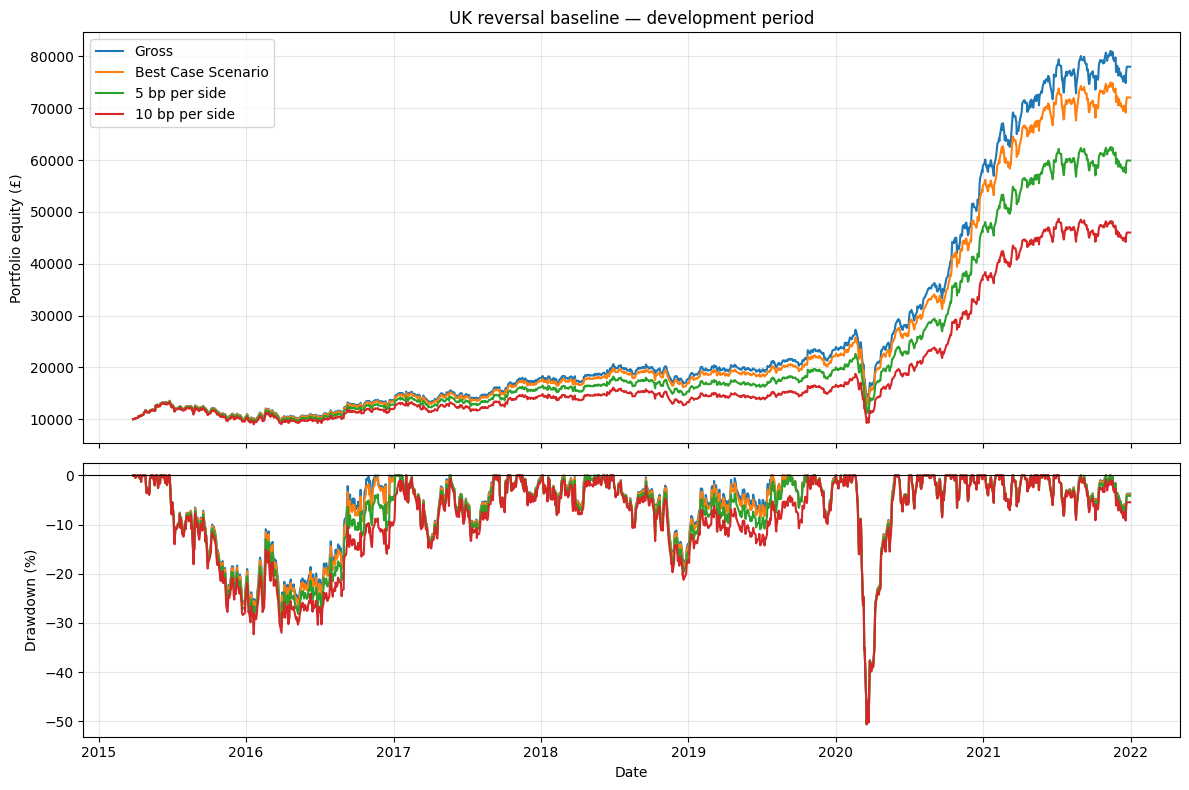

Calendar-year returns (%); first year covers the simulated period only.


,Gross,Best Case Scenario,5 bp per side,10 bp per side
year,,,,
2015,4.94,4.06,2.03,-0.81
2016,29.81,28.35,25.01,20.38
2017,31.46,29.92,26.41,21.56
2018,-0.79,-1.91,-4.47,-8.00
2019,31.75,30.21,26.70,21.86
2020,151.76,148.59,141.36,131.36
2021,32.42,30.84,27.23,22.25


In [28]:
import matplotlib.pyplot as plt
import plotting_reversal_signals

importlib.reload(plotting_reversal_signals)

uk_plot_scenarios = {
    0: "Gross",
    1.5: "Best Case Scenario",
    5: "5 bp per side",
    10: "10 bp per side"
}

uk_equity_curves = pd.DataFrame({label: uk_cost_backtests[cost]["daily"]["equity_gbp"] for cost, label in uk_plot_scenarios.items()})
uk_performance_figure = plotting_reversal_signals.plot_equity_and_drawdown(uk_equity_curves)

#each full year's return starts at previous year-ending valuation.
uk_year_end_equity = uk_equity_curves.groupby(uk_equity_curves.index.year).last()
uk_year_start_equity = uk_year_end_equity.shift(1)
uk_year_start_equity.iloc[0] = UK_BASELINE["initial_capital_gbp"]

uk_annual_returns_pct = 100 * (uk_year_end_equity / uk_year_start_equity - 1)
uk_annual_returns_pct.index.name = "year"

print("Calendar-year returns (%); first year covers the simulated period only.")
display(uk_annual_returns_pct.round(2))

See the largest drawdown happens in ~march 2020, when the pandemic hit, so not the most suprising result to see. Now we compare with a benchmark, what if we just buy all available stocks with equal weights, whilst rebalancing each week to keep the weights the same?

In [29]:
#using same dates and eligibility, just without ranking
uk_benchmark_decisions = uk_decisions[["signal_time", "eligible"]].copy()
uk_benchmark_counts = (uk_benchmark_decisions["eligible"].groupby(level="Date").transform("sum"))

#matching strategy's planned invested fraction on each decision date
uk_benchmark_exposure = uk_decisions["target_weight"].groupby(level="Date").transform("sum")
uk_benchmark_decisions["target_weight"] = uk_benchmark_decisions["eligible"].astype(float).mul(uk_benchmark_exposure).div(uk_benchmark_counts.where(uk_benchmark_counts.gt(0))).fillna(0.0)

uk_exposure_comparison = pd.DataFrame({
    "reversal": uk_decisions["target_weight"].groupby(level="Date").sum(),
    "benchmark": (uk_benchmark_decisions["target_weight"].groupby(level="Date").sum())
})

display(uk_exposure_comparison.head())
print("Same planned invested fraction:", np.allclose(uk_exposure_comparison["reversal"], uk_exposure_comparison["benchmark"]))

,reversal,benchmark
Date,,
2015-03-27,1.0,1.0
2015-04-07,1.0,1.0
2015-04-14,1.0,1.0
2015-04-21,1.0,1.0
2015-04-28,1.0,1.0


Same planned invested fraction: True


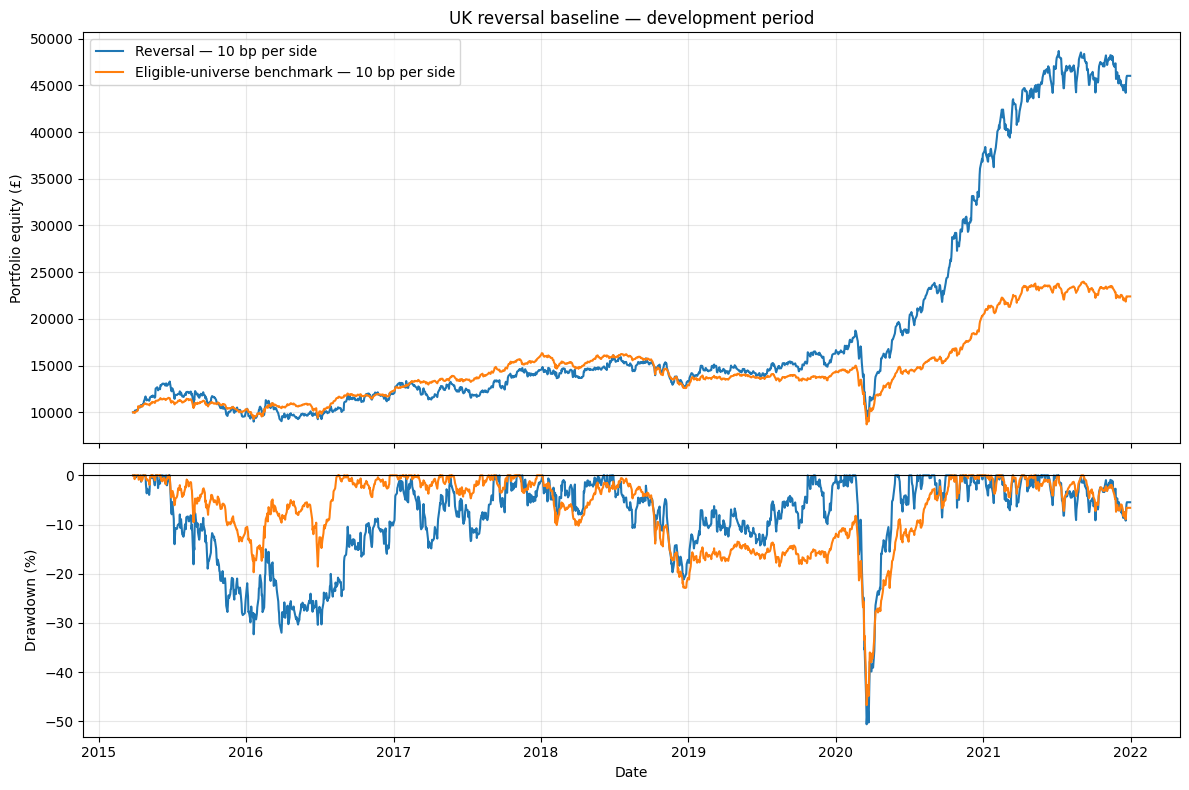

,final_equity_gbp
Reversal — 10 bp per side,46020.96
Eligible-universe benchmark — 10 bp per side,22403.60


In [30]:
UK_PRIMARY_COST_BPS = 10

uk_benchmark_backtest = reversal_backtest.run_execution_backtest(
    decisions=uk_benchmark_decisions,
    market=uk_execution_market,
    schedule=uk_schedule,
    initial_capital_gbp=UK_BASELINE["initial_capital_gbp"],
    holding_sessions=UK_BASELINE["holding_sessions"],
    cost_per_side_bps=UK_PRIMARY_COST_BPS,
    net_orders=True)

uk_benchmark_comparison = pd.DataFrame({
    "Reversal — 10 bp per side": (uk_cost_backtests[UK_PRIMARY_COST_BPS]["daily"]["equity_gbp"]),
    "Eligible-universe benchmark — 10 bp per side": (uk_benchmark_backtest["daily"]["equity_gbp"])
    })

uk_benchmark_figure = plotting_reversal_signals.plot_equity_and_drawdown(uk_benchmark_comparison)
display(uk_benchmark_comparison.iloc[-1].rename("final_equity_gbp").round(2).to_frame())

In [31]:
uk_comparison_year_end = uk_benchmark_comparison.groupby(uk_benchmark_comparison.index.year).last()
uk_comparison_year_start = uk_comparison_year_end.shift(1)
uk_comparison_year_start.iloc[0] = UK_BASELINE["initial_capital_gbp"]

uk_annual_comparison = 100 * (uk_comparison_year_end / uk_comparison_year_start - 1)
uk_annual_comparison.columns = ["reversal_pct", "benchmark_pct"]
uk_annual_comparison.index.name = "year"
uk_annual_comparison["difference_pp"] = (uk_annual_comparison["reversal_pct"]- uk_annual_comparison["benchmark_pct"])

display(uk_annual_comparison.round(2))

,reversal_pct,benchmark_pct,difference_pp
year,,,
2015,-0.81,3.16,-3.97
2016,20.38,19.05,1.33
2017,21.56,30.02,-8.46
2018,-8.00,-19.05,11.05
2019,21.86,10.31,11.55
2020,131.36,43.07,88.29
2021,22.25,9.83,12.42


See the reversal strategy outperforms in most years, with a massive outperformance in 2020 during the post-COVID19 rebound. We now introduce a classic baseline, what if we buy equal weights at the start, and do not rebalance again?

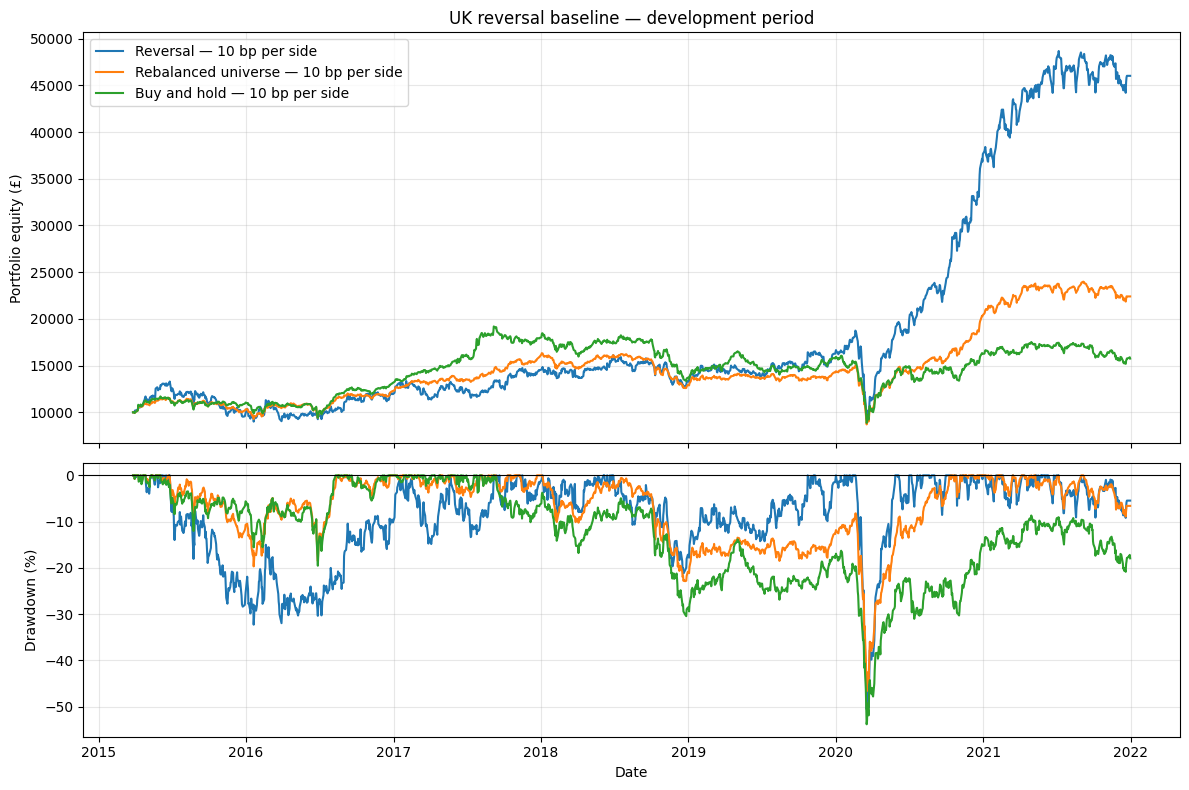

,final_equity_gbp
Reversal — 10 bp per side,46020.96
Rebalanced universe — 10 bp per side,22403.60
Buy and hold — 10 bp per side,15747.45


,,orders
side,status,
buy,assumed_fill,44
sell,assumed_fill,44


Positions remaining: 0


In [32]:
#keep only initial allocation, and do not rebalance (buy and hold)
uk_buy_hold_decisions = uk_benchmark_decisions.xs(uk_decision_dates[0], level="Date", drop_level=False).copy()

#enter next session, and exit at open on final development session
uk_buy_hold_entry_position = uk_schedule.index.get_loc(uk_decision_dates[0]) + 1
uk_buy_hold_horizon = int(len(uk_schedule) - 1 - uk_buy_hold_entry_position)

uk_buy_hold_backtest = reversal_backtest.run_execution_backtest(
    decisions=uk_buy_hold_decisions,
    market=uk_execution_market,
    schedule=uk_schedule,
    initial_capital_gbp=UK_BASELINE["initial_capital_gbp"],
    holding_sessions=uk_buy_hold_horizon,
    cost_per_side_bps=UK_PRIMARY_COST_BPS,
    net_orders=True
)

uk_cost_label = f"{UK_PRIMARY_COST_BPS:g} bp per side"

uk_three_way_comparison = pd.DataFrame({
    f"Reversal — {uk_cost_label}": (uk_cost_backtests[UK_PRIMARY_COST_BPS]["daily"]["equity_gbp"]),
    f"Rebalanced universe — {uk_cost_label}": (uk_benchmark_backtest["daily"]["equity_gbp"]),
    f"Buy and hold — {uk_cost_label}": (uk_buy_hold_backtest["daily"]["equity_gbp"])
})

uk_three_way_figure = (plotting_reversal_signals.plot_equity_and_drawdown(uk_three_way_comparison))

display(uk_three_way_comparison.iloc[-1].rename("final_equity_gbp").round(2).to_frame())
display(uk_buy_hold_backtest["orders"].groupby(["side", "status"]).size().rename("orders").to_frame())
print("Positions remaining:",len(uk_buy_hold_backtest["final_positions"]))

See that the reversal signals outperforms both baselines by significant margins over this period. We check to see if any exceptional trades are what make the difference, or just a general outperformance over time.

In [33]:
importlib.reload(reversal_validation)

uk_stock_attribution = reversal_validation.attribute_stock_pnl(result=uk_cost_backtests[UK_PRIMARY_COST_BPS], market=uk_execution_market, initial_capital_gbp=UK_BASELINE["initial_capital_gbp"])
uk_attribution_columns = ["net_pnl_gbp", "dividends_gbp", "cost_gbp", "traded_notional_gbp"]

print("Largest positive contributions:")
display(uk_stock_attribution[uk_attribution_columns].head(10).round(2))

print("Largest negative contributions:")
display(uk_stock_attribution[uk_attribution_columns].tail(10).sort_values("net_pnl_gbp").round(2))

uk_stock_pnl = uk_stock_attribution["net_pnl_gbp"]
uk_positive_pnl = uk_stock_pnl.clip(lower=0)

print("Total net P&L (£):", round(uk_stock_pnl.sum(), 2))
print("Profitable stocks:", int(uk_stock_pnl.gt(0).sum()), "/", len(uk_stock_pnl))

if uk_positive_pnl.sum() > 0:
    print("Top five share of positive stock contributions (%):", round(100 * uk_positive_pnl.nlargest(5).sum() / uk_positive_pnl.sum(), 2))

Largest positive contributions:


,net_pnl_gbp,dividends_gbp,cost_gbp,traded_notional_gbp
ticker,,,,
UFO.L,2334.62,0.00,34.41,34414.89
AVCT.L,2130.11,0.00,58.53,58527.69
TRUE.L,2071.50,0.00,43.54,43542.32
GGP.L,1994.19,0.00,94.92,94916.74
PANR.L,1885.31,0.00,103.15,103154.79
VAL.L,1424.39,0.00,47.48,47483.91
CRTX.L,1391.35,0.00,85.39,85391.70
PREM.L,1333.17,0.00,86.61,86609.49
STAF.L,1324.93,13.05,89.96,89957.48


Largest negative contributions:


,net_pnl_gbp,dividends_gbp,cost_gbp,traded_notional_gbp
ticker,,,,
PDL.L,-2213.43,0.0,116.66,116657.18
RKH.L,-1696.91,0.0,100.89,100885.31
MTC.L,-1287.04,0.0,40.74,40737.90
GENL.L,-1283.57,69.8,129.51,129508.37
OMI.L,-1090.33,0.0,40.97,40974.79
88E.L,-986.49,0.0,101.20,101199.92
ARS.L,-919.24,0.0,60.55,60546.90
SORT.L,-811.92,0.0,9.14,9141.08
PRD.L,-724.45,0.0,22.21,22210.64


Total net P&L (£): 36020.96
Profitable stocks: 176 / 286
Top five share of positive stock contributions (%): 16.14


In [34]:
uk_benchmark_stock_attribution = reversal_validation.attribute_stock_pnl(
    result=uk_benchmark_backtest,
    market=uk_execution_market,
    initial_capital_gbp=UK_BASELINE["initial_capital_gbp"]
)

#a stock absent from a portfolio contributes zero to that portfolio
uk_stock_pnl_comparison = pd.DataFrame({
    "reversal_pnl_gbp": uk_stock_attribution["net_pnl_gbp"],
    "benchmark_pnl_gbp": uk_benchmark_stock_attribution["net_pnl_gbp"],
}).fillna(0.0)

uk_stock_pnl_comparison["difference_gbp"] = uk_stock_pnl_comparison["reversal_pnl_gbp"] - uk_stock_pnl_comparison["benchmark_pnl_gbp"]
uk_stock_pnl_comparison = uk_stock_pnl_comparison.sort_values("difference_gbp", ascending=False)

print("Largest contributions to outperformance:")
display(uk_stock_pnl_comparison.head(10).round(2))
print("Largest detractors:")
display(uk_stock_pnl_comparison.tail(10).sort_values("difference_gbp").round(2))
print("Total final-wealth difference (£):", round(uk_stock_pnl_comparison["difference_gbp"].sum(), 2))

Largest contributions to outperformance:


,reversal_pnl_gbp,benchmark_pnl_gbp,difference_gbp
ticker,,,
UFO.L,2334.62,190.10,2144.52
AVCT.L,2130.11,329.24,1800.88
TRUE.L,2071.50,338.82,1732.68
PANR.L,1885.31,237.85,1647.47
PREM.L,1333.17,-270.59,1603.77
CRTX.L,1391.35,-95.63,1486.98
STAF.L,1324.93,-8.91,1333.84
VAL.L,1424.39,113.38,1311.01
XLM.L,1148.06,-4.67,1152.72


Largest detractors:


,reversal_pnl_gbp,benchmark_pnl_gbp,difference_gbp
ticker,,,
PDL.L,-2213.43,-428.67,-1784.76
88E.L,-986.49,715.00,-1701.49
RKH.L,-1696.91,-163.95,-1532.96
GENL.L,-1283.57,-35.64,-1247.94
MTC.L,-1287.04,-140.44,-1146.60
OMI.L,-1090.33,-60.04,-1030.29
ARS.L,-919.24,-54.58,-864.66
PRD.L,-724.45,-53.28,-671.17
FEVR.L,-94.78,563.86,-658.64


Total final-wealth difference (£): 23617.36


In [35]:
UK_BASELINE_INFERENCE = {
    "primary_block_sessions": 20,
    "block_sessions": (20, 5, 60),
    "n_bootstrap": 10_000,
    "seed": 42,
}

uk_paired_equity = pd.DataFrame({
    "reversal": (uk_cost_backtests[UK_PRIMARY_COST_BPS]["daily"]["equity_gbp"]),
    "benchmark": uk_benchmark_backtest["daily"]["equity_gbp"]
})
if not np.isfinite(uk_paired_equity.to_numpy()).all():
    raise ValueError("Resolve missing or mismatched equity observations.")

#remove only first observation, which has no preceding valuation
uk_paired_returns = uk_paired_equity.pct_change(fill_method=None).iloc[1:]
uk_daily_excess = (uk_paired_returns["reversal"] - uk_paired_returns["benchmark"]).to_frame("net_excess")

if not np.isfinite(uk_daily_excess.to_numpy()).all():
    raise ValueError("Resolve unknown returns before inference.")

uk_inference_rows = []
for block_sessions in UK_BASELINE_INFERENCE["block_sessions"]:
    draws = reversal_validation.bootstrap_block_means(
        uk_daily_excess,
        block_length=block_sessions,
        n_bootstrap=UK_BASELINE_INFERENCE["n_bootstrap"],
        seed=UK_BASELINE_INFERENCE["seed"])["net_excess"]
    lower, upper = draws.quantile([0.025, 0.975])

    uk_inference_rows.append({
        "block_sessions": block_sessions,
        "primary": (block_sessions == UK_BASELINE_INFERENCE["primary_block_sessions"]),
        "mean_daily_excess_bps": 10_000 * uk_daily_excess["net_excess"].mean(),
        "lower_95_bps": 10_000 * lower,
        "upper_95_bps": 10_000 * upper,
    })

uk_baseline_uncertainty = pd.DataFrame(uk_inference_rows).set_index("block_sessions")
display(uk_baseline_uncertainty.round(3))

,primary,mean_daily_excess_bps,lower_95_bps,upper_95_bps
block_sessions,,,,
20,True,5.155,0.257,10.180
5,False,5.155,-0.153,10.397
60,False,5.155,1.066,9.380


## **Sweeping**

In [36]:
from itertools import product

UK_SWEEP_SPEC = {
    "formation_sessions": (1, 3, 5, 10),
    "top_frac": (0.10, 0.20, 0.30),
    "holding_sessions": (1, 3, 5)
}

uk_sweep_grid = pd.DataFrame(product(*UK_SWEEP_SPEC.values()), columns=list(UK_SWEEP_SPEC)).rename_axis("configuration_id")
uk_sweep_grid["rebalance_sessions"] = uk_sweep_grid["holding_sessions"]
uk_sweep_grid["is_baseline"] = (uk_sweep_grid["formation_sessions"].eq(UK_BASELINE["formation_sessions"])
    & uk_sweep_grid["top_frac"].eq(UK_BASELINE["top_frac"])
    & uk_sweep_grid["holding_sessions"].eq(UK_BASELINE["holding_sessions"]) \
    & uk_sweep_grid["rebalance_sessions"].eq(UK_BASELINE["rebalance_sessions"]))

print("Configurations:", len(uk_sweep_grid))
display(uk_sweep_grid.head(9))
display(uk_sweep_grid.loc[uk_sweep_grid["is_baseline"]])

Configurations: 36


,formation_sessions,top_frac,holding_sessions,rebalance_sessions,is_baseline
configuration_id,,,,,
0,1,0.1,1,1,False
1,1,0.1,3,3,False
2,1,0.1,5,5,False
3,1,0.2,1,1,False
4,1,0.2,3,3,False
5,1,0.2,5,5,False
6,1,0.3,1,1,False
7,1,0.3,3,3,False
8,1,0.3,5,5,False


,formation_sessions,top_frac,holding_sessions,rebalance_sessions,is_baseline
configuration_id,,,,,
23,5,0.2,5,5,True


In [37]:
uk_formation_windows = sorted(uk_sweep_grid["formation_sessions"].unique().tolist())
uk_sweep_closes = uk_prices.set_index("ticker", append=True)["adj_close"].sort_index()

if not uk_sweep_closes.index.equals(uk_features.index):
    raise ValueError("Price and eligibility rows do not match.")

uk_sweep_valid_close = np.isfinite(uk_sweep_closes) & uk_sweep_closes.gt(0)
uk_sweep_window = max(uk_formation_windows) + 1

uk_sweep_complete = (uk_sweep_valid_close.groupby(level="ticker", sort=False)
    .transform(lambda values: values.rolling(uk_sweep_window, min_periods=uk_sweep_window).sum().eq(uk_sweep_window)))

#retain established liquidity and signal-day volume filters
uk_sweep_common_eligible = uk_features["eligible"].copy()
if UK_ELIGIBILITY["require_complete_formation_window"]:
    uk_sweep_common_eligible &= uk_sweep_complete

uk_sweep_features = {}
for lookback in uk_formation_windows:
    panel = reversal_features.build_raw_reversal_features(uk_prices, uk_schedule, lookback=lookback).set_index("ticker", append=True).sort_index()

    if not panel.index.equals(uk_features.index):
        raise ValueError("Formation panels have mismatched rows.")

    uk_sweep_common_eligible &= np.isfinite(panel["raw_reversal_score"])
    uk_sweep_features[lookback] = panel

#assign completed common mask to each formation window
for panel in uk_sweep_features.values():
    panel["eligible"] = uk_sweep_common_eligible

print("Formation windows:", uk_formation_windows)
print("Common eligible stock-date rows:", int(uk_sweep_common_eligible.sum()))
print("Rows removed from baseline eligibility:", int((uk_features["eligible"] & ~uk_sweep_common_eligible).sum()))
display(uk_sweep_features[5].loc[uk_sweep_common_eligible, ["raw_reversal_score", "eligible"]].head())

Formation windows: [1, 3, 5, 10]
Common eligible stock-date rows: 154937
Rows removed from baseline eligibility: 0


raw_reversal_score  eligible
Date       ticker                              
2015-03-27 AMS.L             0.012324      True
           BME.L             0.005691      True
           BOOM.L           -0.075758      True
           CCT.L            -0.022727      True
           CRTX.L           -0.499423      True

In [38]:
uk_sweep_warmup = max(UK_ELIGIBILITY["liquidity_lookback_sessions"], max(uk_formation_windows))
uk_sweep_start = uk_schedule.index[uk_sweep_warmup]
uk_sweep_valuation_dates = uk_schedule.loc[uk_sweep_start:].index
uk_sweep_positions = np.arange(len(uk_schedule))

if uk_sweep_valuation_dates[-1] >= pd.Timestamp(UK_PERIODS["holdout_start"]):
    raise ValueError("The sweep must remain within development data.")

uk_sweep_decision_dates = {}
uk_sweep_calendar_rows = []
for holding in sorted(uk_sweep_grid["holding_sessions"].unique().tolist()):
    calendar = reversal_validation.build_rebalance_calendar(
        uk_schedule,
        anchor=uk_sweep_start,
        rebalance_sessions=holding)

    #allow entry next session and a complete holding period
    dates = uk_schedule.index[calendar["is_rebalance"].to_numpy() & (uk_sweep_positions + 1 + holding < len(uk_schedule))]
    uk_sweep_decision_dates[holding] = dates
    last_signal_position = uk_schedule.index.get_loc(dates[-1])

    uk_sweep_calendar_rows.append({
        "holding_sessions": holding,
        "decision_dates": len(dates),
        "first_signal": dates[0],
        "last_signal": dates[-1],
        "last_planned_exit": uk_schedule.index[last_signal_position + 1 + holding]
    })

uk_sweep_calendar_summary = pd.DataFrame(uk_sweep_calendar_rows).set_index("holding_sessions")
display(uk_sweep_calendar_summary)
print("Baseline decision dates preserved:", uk_sweep_decision_dates[UK_BASELINE["holding_sessions"]].equals(uk_decision_dates))

,decision_dates,first_signal,last_signal,last_planned_exit
holding_sessions,,,,
1,1709,2015-03-27,2021-12-29,2021-12-31
3,569,2015-03-27,2021-12-21,2021-12-29
5,341,2015-03-27,2021-12-15,2021-12-23


Baseline decision dates preserved: True


In [39]:
importlib.reload(reversal_validation)

uk_baseline_id = uk_sweep_grid.index[uk_sweep_grid["is_baseline"]].item()
uk_baseline_config = uk_sweep_grid.loc[uk_baseline_id]
uk_sweep_baseline = reversal_validation.evaluate_execution_configuration(feature_panel=uk_sweep_features[int(uk_baseline_config["formation_sessions"])],
    decision_dates=uk_sweep_decision_dates[int(uk_baseline_config["holding_sessions"])],
    market=uk_execution_market,
    schedule=uk_schedule,
    top_frac=float(uk_baseline_config["top_frac"]),
    holding_sessions=int(uk_baseline_config["holding_sessions"]),
    min_eligible=UK_BASELINE["min_eligible"],
    initial_capital_gbp=UK_BASELINE["initial_capital_gbp"],
    cost_per_side_bps=UK_PRIMARY_COST_BPS
)

for name, previous in {"strategy": uk_cost_backtests[UK_PRIMARY_COST_BPS], "benchmark": uk_benchmark_backtest}.items():
    actual = uk_sweep_baseline[name]["daily"]

    pd.testing.assert_index_equal(actual.index, uk_sweep_valuation_dates)
    pd.testing.assert_frame_equal(actual, previous["daily"], check_exact=False, rtol=1e-10, atol=1e-6)
print(f"Configuration {uk_baseline_id}: both daily backtests reproduce the baseline.")

Configuration 23: both daily backtests reproduce the baseline.


In [40]:
UK_SWEEP_RULES = {
    "cost_per_side_bps": 10,
    "hac_lags": 20,
    "hac_kernel": "bartlett",
    "hac_use_correction": True,
    "hac_use_t": False,
    "familywise_alpha": 0.05,
    "alternative": "greater",
    "multiple_testing": "holm",
}

uk_sweep_daily = {}

for configuration in uk_sweep_grid.itertuples():
    result = reversal_validation.evaluate_execution_configuration(
        feature_panel=uk_sweep_features[configuration.formation_sessions],
        decision_dates=uk_sweep_decision_dates[configuration.holding_sessions],
        market=uk_execution_market,
        schedule=uk_schedule,
        top_frac=configuration.top_frac,
        holding_sessions=configuration.holding_sessions,
        min_eligible=UK_BASELINE["min_eligible"],
        initial_capital_gbp=UK_BASELINE["initial_capital_gbp"],
        cost_per_side_bps=UK_SWEEP_RULES["cost_per_side_bps"]
    )

    #keep daily curves, diagnostics without keeping every order ledger
    components = []
    for name in ["strategy", "benchmark"]:
        daily = result[name]["daily"][["equity_gbp", "cost_gbp", "stale_value_gbp", "positions"]].copy()
        components.append(daily.add_prefix(f"{name}_"))
    paired = pd.concat(components, axis=1)
    pd.testing.assert_index_equal(paired.index, uk_sweep_valuation_dates)
    if not np.isfinite(paired.to_numpy()).all():
        raise ValueError(f"Configuration {configuration.Index} has unknown daily values.")

    uk_sweep_daily[configuration.Index] = paired
    del result
    print(f"Completed {len(uk_sweep_daily)}/{len(uk_sweep_grid)}", flush=True)

#remove only initial cash valuations's undefined return
uk_sweep_net_excess = pd.DataFrame({
    configuration_id: daily["strategy_equity_gbp"].pct_change(fill_method=None) - daily["benchmark_equity_gbp"].pct_change(fill_method=None)
    for configuration_id, daily in uk_sweep_daily.items()}).iloc[1:].rename_axis(columns="configuration_id")

if not np.isfinite(uk_sweep_net_excess.to_numpy()).all():
    raise ValueError("Resolve unknown returns before comparing configurations.")

uk_sweep_summary = uk_sweep_grid.join(uk_sweep_net_excess.mean().mul(10_000).rename("mean_daily_net_excess_bps"), validate="one_to_one")
display(uk_sweep_summary.round(3))

Completed 1/36
Completed 2/36
Completed 3/36
Completed 4/36
Completed 5/36
Completed 6/36
Completed 7/36
Completed 8/36
Completed 9/36
Completed 10/36
Completed 11/36
Completed 12/36
Completed 13/36
Completed 14/36
Completed 15/36
Completed 16/36
Completed 17/36
Completed 18/36
Completed 19/36
Completed 20/36
Completed 21/36
Completed 22/36
Completed 23/36
Completed 24/36
Completed 25/36
Completed 26/36
Completed 27/36
Completed 28/36
Completed 29/36
Completed 30/36
Completed 31/36
Completed 32/36
Completed 33/36
Completed 34/36
Completed 35/36
Completed 36/36


,formation_sessions,top_frac,holding_sessions,rebalance_sessions,is_baseline,mean_daily_net_excess_bps
configuration_id,,,,,,
0,1,0.1,1,1,False,-16.790
1,1,0.1,3,3,False,5.615
2,1,0.1,5,5,False,0.610
3,1,0.2,1,1,False,-21.821
4,1,0.2,3,3,False,-1.894
5,1,0.2,5,5,False,-0.608
6,1,0.3,1,1,False,-21.189
7,1,0.3,3,3,False,-2.618
8,1,0.3,5,5,False,-1.083


In [41]:
pd.testing.assert_index_equal(uk_sweep_net_excess.index, uk_sweep_valuation_dates[1:])

#test complete grid before sorting or filtering
uk_sweep_inference = reversal_validation.infer_sweep_means(
    net_returns=uk_sweep_net_excess,
    grid=uk_sweep_grid,
    rules=UK_SWEEP_RULES
)
uk_sweep_test_results = uk_sweep_grid.join(uk_sweep_inference, validate="one_to_one")

print("Configurations tested:", len(uk_sweep_test_results))
print("Positive-mean tests passing Holm correction:", int(uk_sweep_test_results["reject_holm"].sum()),)

display(uk_sweep_test_results[[
            "formation_sessions",
            "top_frac",
            "holding_sessions",
            "mean_bps",
            "hac_se_bps",
            "p_one_sided",
            "p_holm",
            "reject_holm"
        ]].sort_values("p_one_sided").style.format({
        "top_frac": "{:.0%}",
        "mean_bps": "{:.3f}",
        "hac_se_bps": "{:.3f}",
        "p_one_sided": "{:.4g}",
        "p_holm": "{:.4g}",
    }))

Configurations tested: 36
Positive-mean tests passing Holm correction: 5


,formation_sessions,top_frac,holding_sessions,mean_bps,hac_se_bps,p_one_sided,p_holm,reject_holm
configuration_id,,,,,,,,
27,10,10%,1,22.991,4.180,1.899e-08,6.836e-07,True
18,5,10%,1,17.332,3.678,1.224e-06,4.285e-05,True
28,10,10%,3,19.271,4.372,5.228e-06,0.0001778,True
9,3,10%,1,16.283,4.036,2.732e-05,0.0009014,True
19,5,10%,3,11.817,3.671,0.0006424,0.02056,True
29,10,10%,5,11.685,4.185,0.002616,0.08109,False
10,3,10%,3,12.649,4.672,0.003388,0.1016,False
31,10,20%,3,6.573,2.563,0.005161,0.1497,False
30,10,20%,1,6.907,2.696,0.005209,0.1497,False


## **Walk-Forward**

In [42]:
UK_WF_RULES = {
    "initial_train_sessions": 504,
    "test_sessions": 63,
    "selection_metric": "mean_daily_net_excess",
    "minimum_training_mean": 0.0,
    "tie_break": "lowest_configuration_id",
    "cost_per_side_bps": UK_SWEEP_RULES["cost_per_side_bps"]
}

uk_wf_return_dates = uk_sweep_net_excess.index
pd.testing.assert_index_equal(uk_wf_return_dates, uk_sweep_valuation_dates[1:])
if uk_wf_return_dates[-1] >= pd.Timestamp(UK_PERIODS["holdout_start"]):
    raise ValueError("Walk-forward development must exclude the holdout.")

import reversal_walk_forward

importlib.reload(reversal_walk_forward)

uk_wf_folds = reversal_walk_forward.build_walk_forward_folds(net_returns=uk_sweep_net_excess, schedule=uk_schedule, initial_train_sessions=UK_WF_RULES["initial_train_sessions"], test_sessions=UK_WF_RULES["test_sessions"])

print("Walk-forward periods:", len(uk_wf_folds))
display(uk_wf_folds.head(3))
display(uk_wf_folds.tail(1))

Walk-forward periods: 20


,train_start,train_end,selection_date,selection_time,test_start,test_end,train_sessions,test_sessions
fold,,,,,,,,
0,2015-03-30,2017-03-24,2017-03-24,2017-03-24 16:30:00+00:00,2017-03-27,2017-06-27,504,63
1,2015-03-30,2017-06-27,2017-06-27,2017-06-27 15:30:00+00:00,2017-06-28,2017-09-25,567,63
2,2015-03-30,2017-09-25,2017-09-25,2017-09-25 15:30:00+00:00,2017-09-26,2017-12-21,630,63


,train_start,train_end,selection_date,selection_time,test_start,test_end,train_sessions,test_sessions
fold,,,,,,,,
19,2015-03-30,2021-12-16,2021-12-16,2021-12-16 16:30:00+00:00,2021-12-17,2021-12-31,1701,9


In [43]:
importlib.reload(reversal_walk_forward)

uk_wf_choices = reversal_walk_forward.select_walk_forward_configurations(net_returns=uk_sweep_net_excess, folds=uk_wf_folds, grid=uk_sweep_grid, rules=UK_WF_RULES)
display(uk_wf_choices[[
            "selection_date",
            "test_start",
            "test_end",
            "configuration_id",
            "formation_sessions",
            "top_frac",
            "holding_sessions",
            "best_training_mean_bps",
            "allow_new_entries"]].round(3))
print("Periods allowing new entries:", int(uk_wf_choices["allow_new_entries"].sum()), "/", len(uk_wf_choices))

,selection_date,test_start,test_end,configuration_id,formation_sessions,top_frac,holding_sessions,best_training_mean_bps,allow_new_entries
fold,,,,,,,,,
0,2017-03-24,2017-03-27,2017-06-27,18,5,0.1,1,18.010,True
1,2017-06-27,2017-06-28,2017-09-25,18,5,0.1,1,18.278,True
2,2017-09-25,2017-09-26,2017-12-21,27,10,0.1,1,18.047,True
3,2017-12-21,2017-12-22,2018-03-23,9,3,0.1,1,21.967,True
4,2018-03-23,2018-03-26,2018-06-26,9,3,0.1,1,22.820,True
5,2018-06-26,2018-06-27,2018-09-24,9,3,0.1,1,18.830,True
6,2018-09-24,2018-09-25,2018-12-20,9,3,0.1,1,20.039,True
7,2018-12-20,2018-12-21,2019-03-22,9,3,0.1,1,21.650,True
8,2019-03-22,2019-03-25,2019-06-25,9,3,0.1,1,21.351,True


Periods allowing new entries: 20 / 20


In [44]:
importlib.reload(reversal_walk_forward)

uk_wf_decisions = reversal_walk_forward.build_walk_forward_decisions(
    choices=uk_wf_choices,
    feature_panels=uk_sweep_features,
    decision_dates_by_holding=uk_sweep_decision_dates,
    min_eligible=UK_BASELINE["min_eligible"])
uk_wf_decision_plan = uk_wf_decisions.groupby(level="Date").agg(
    configuration_id=("configuration_id", "first"),
    holding_sessions=("holding_sessions", "first"),
    selected_count=("selected", "sum"),
    invested_fraction=("target_weight", "sum"))

print("Decision dates:", len(uk_wf_decision_plan))
display(uk_wf_decision_plan.head())
display(uk_wf_decision_plan.tail())

Decision dates: 1205


,configuration_id,holding_sessions,selected_count,invested_fraction
Date,,,,
2017-03-24,18,1,8,1.0
2017-03-27,18,1,9,1.0
2017-03-28,18,1,9,1.0
2017-03-29,18,1,9,1.0
2017-03-30,18,1,9,1.0


,configuration_id,holding_sessions,selected_count,invested_fraction
Date,,,,
2021-12-21,27,1,16,1.0
2021-12-22,27,1,16,1.0
2021-12-23,27,1,15,1.0
2021-12-24,27,1,15,1.0
2021-12-29,27,1,15,1.0


In [45]:
importlib.reload(reversal_backtest)

uk_wf_strategy = reversal_backtest.run_execution_backtest(
    decisions=uk_wf_decisions,
    market=uk_execution_market,
    schedule=uk_schedule,
    initial_capital_gbp=UK_BASELINE["initial_capital_gbp"],
    cost_per_side_bps=UK_WF_RULES["cost_per_side_bps"],
    net_orders=True,
    holding_sessions_by_date=uk_wf_decision_plan["holding_sessions"],
)

uk_wf_daily = uk_wf_strategy["daily"]

print("Valuation period:", uk_wf_daily.index[0].date(), "to", uk_wf_daily.index[-1].date())
print(f"Starting equity: £{uk_wf_daily['equity_gbp'].iloc[0]:,.2f}")
print(f"Final equity: £{uk_wf_daily['equity_gbp'].iloc[-1]:,.2f}")
print(f"Total modelled costs: £{uk_wf_daily['cost_gbp'].sum():,.2f}")

display(uk_wf_daily[["equity_gbp", "cash_gbp", "cost_gbp", "positions", "stale_value_gbp"]].tail())

Valuation period: 2017-03-24 to 2021-12-31
Starting equity: £10,000.00
Final equity: £179,136.33
Total modelled costs: £40,435.83


,equity_gbp,cash_gbp,cost_gbp,positions,stale_value_gbp
Date,,,,,
2021-12-23,170231.345152,8.872613e+02,108.088297,16,0.0
2021-12-24,172887.494051,1.818989e-12,109.098172,15,0.0
2021-12-29,176797.732069,7.859515e+02,138.895487,15,0.0
2021-12-30,178908.812335,5.358901e+02,97.969848,15,0.0
2021-12-31,179136.327089,1.781050e+05,177.746834,0,0.0


These results look amazing on the surface, but this is still a development phase, where a period of 2022-2023 is held out for testing. We compare with the benchmark below (holding equal weights across the universe, with rebalancing at the same time as the strategy), including plotting the corresponding equity curves.

In [46]:
uk_wf_benchmark_decisions = uk_wf_decisions[["signal_time", "eligible"]].copy()
uk_wf_benchmark_counts = uk_wf_benchmark_decisions["eligible"].groupby(level="Date").transform("sum")
uk_wf_benchmark_exposure = uk_wf_decisions["target_weight"].groupby(level="Date").transform("sum")
uk_wf_benchmark_decisions["target_weight"] = uk_wf_benchmark_decisions["eligible"].astype(float).mul(uk_wf_benchmark_exposure).div(uk_wf_benchmark_counts.where(uk_wf_benchmark_counts.gt(0))).fillna(0.0)

uk_wf_benchmark = reversal_backtest.run_execution_backtest(
    decisions=uk_wf_benchmark_decisions,
    market=uk_execution_market,
    schedule=uk_schedule,
    initial_capital_gbp=UK_BASELINE["initial_capital_gbp"],
    cost_per_side_bps=UK_WF_RULES["cost_per_side_bps"],
    net_orders=True,
    holding_sessions_by_date=uk_wf_decision_plan["holding_sessions"]
)

pd.testing.assert_index_equal(uk_wf_daily.index, uk_wf_benchmark["daily"].index)
uk_wf_equity = pd.DataFrame({
    "Walk-forward": uk_wf_daily["equity_gbp"],
    "Matched benchmark": uk_wf_benchmark["daily"]["equity_gbp"]
})
display(uk_wf_equity.iloc[-1].rename("final_equity_gbp").round(2).to_frame())

,final_equity_gbp
Walk-forward,179136.33
Matched benchmark,18833.32


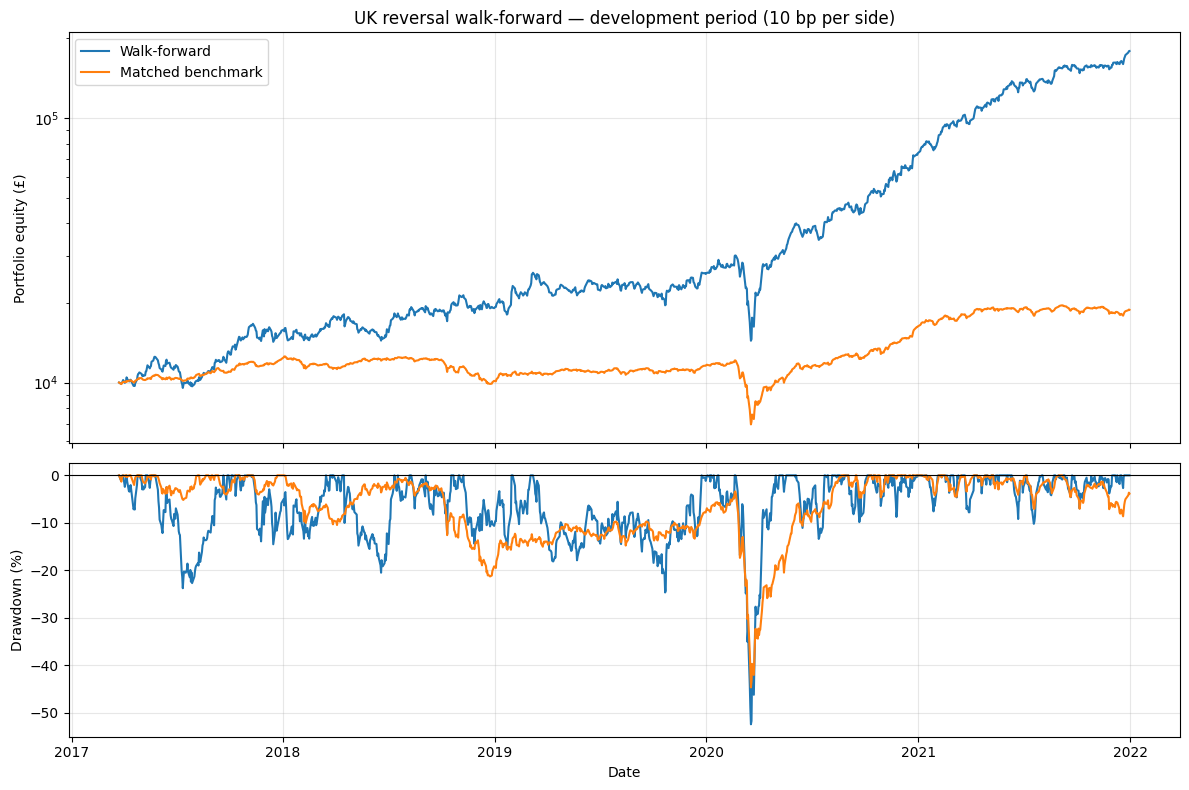

In [47]:
import importlib
import plotting_reversal_signals

importlib.reload(plotting_reversal_signals)

uk_wf_figure = plotting_reversal_signals.plot_equity_and_drawdown(uk_wf_equity, title=(
        "UK reversal walk-forward — development period "
        f"({UK_WF_RULES['cost_per_side_bps']:g} bp per side)"), log_equity=True)

In [48]:
UK_WF_INFERENCE = UK_SWEEP_RULES.copy()

#both equity curves include respective trading costs
uk_wf_paired_returns = (uk_wf_equity.pct_change(fill_method=None).iloc[1:])
uk_wf_net_excess = (uk_wf_paired_returns["Walk-forward"] - uk_wf_paired_returns["Matched benchmark"]).to_frame("walk_forward").rename_axis(columns="configuration_id")

if not np.isfinite(uk_wf_net_excess.to_numpy()).all():
    raise ValueError("Resolve missing returns before inference.")

uk_wf_expected_dates = uk_schedule.loc[uk_wf_choices["test_start"].iloc[0]: uk_wf_choices["test_end"].iloc[-1]].index
pd.testing.assert_index_equal(uk_wf_net_excess.index, uk_wf_expected_dates)

#reuse tested helper for single walk-forward
uk_wf_inference = reversal_validation.infer_sweep_means(net_returns=uk_wf_net_excess, grid=pd.DataFrame(index=uk_wf_net_excess.columns), rules=UK_WF_INFERENCE)
display(uk_wf_inference[[
        "periods",
        "mean_bps",
        "hac_se_bps",
        "ci_lower_bps",
        "ci_upper_bps",
        "p_one_sided",
    ]].style.format({
        "mean_bps": "{:.3f}",
        "hac_se_bps": "{:.3f}",
        "ci_lower_bps": "{:.3f}",
        "ci_upper_bps": "{:.3f}",
        "p_one_sided": "{:.4g}",
    }))

print("Positive mean at 5% (development diagnostic):",bool(uk_wf_inference.loc["walk_forward", "p_one_sided"] < UK_WF_INFERENCE["familywise_alpha"]))

,periods,mean_bps,hac_se_bps,ci_lower_bps,ci_upper_bps,p_one_sided
configuration_id,,,,,,
walk_forward,1206,21.120,4.971,11.377,30.862,1.075e-05


Positive mean at 5% (development diagnostic): True


These results look very promising. We verify its sensitivity to transaction costs.

In [49]:
UK_WF_COST_SCENARIOS = (5, 10, 25, 40, 50)

uk_wf_cost_daily = {UK_WF_RULES["cost_per_side_bps"]: {"Walk-forward": uk_wf_daily, "Matched benchmark": uk_wf_benchmark["daily"]}}
uk_wf_cost_rows = []

for cost in UK_WF_COST_SCENARIOS:
    if cost not in uk_wf_cost_daily:
        uk_wf_cost_daily[cost] = {}

        for name, targets in {"Walk-forward": uk_wf_decisions, "Matched benchmark": uk_wf_benchmark_decisions}.items():
            result = reversal_backtest.run_execution_backtest(
                decisions=targets,
                market=uk_execution_market,
                schedule=uk_schedule,
                initial_capital_gbp=UK_BASELINE["initial_capital_gbp"],
                cost_per_side_bps=cost,
                net_orders=True,
                holding_sessions_by_date=(uk_wf_decision_plan["holding_sessions"])
            )

            pd.testing.assert_index_equal(result["daily"].index, uk_wf_daily.index)

            #retain daily results without storing each scenarios trades
            uk_wf_cost_daily[cost][name] = result["daily"]
            del result

    strategy = uk_wf_cost_daily[cost]["Walk-forward"]
    benchmark = uk_wf_cost_daily[cost]["Matched benchmark"]
    net_excess = (strategy["equity_return"] - benchmark["equity_return"]).iloc[1:]

    if not np.isfinite(net_excess.to_numpy()).all():
        raise ValueError(f"Unknown returns at {cost} bp per side.")
    uk_wf_cost_rows.append({
        "cost_per_side_bps": cost,
        "strategy_final_gbp": strategy["equity_gbp"].iloc[-1],
        "benchmark_final_gbp": benchmark["equity_gbp"].iloc[-1],
        "mean_daily_net_excess_bps": 10_000 * net_excess.mean(),
        "strategy_costs_gbp": strategy["cost_gbp"].sum(),
        "benchmark_costs_gbp": benchmark["cost_gbp"].sum()
    })

uk_wf_cost_summary = pd.DataFrame(uk_wf_cost_rows).set_index("cost_per_side_bps")
display(uk_wf_cost_summary.round(2))

,strategy_final_gbp,benchmark_final_gbp,mean_daily_net_excess_bps,strategy_costs_gbp,benchmark_costs_gbp
cost_per_side_bps,,,,,
5,297076.67,19390.59,25.09,29563.05,369.88
10,179136.33,18833.32,21.12,40435.83,727.68
25,39341.08,17258.23,9.23,36399.42,1732.41
40,8684.51,15818.37,-2.62,26121.05,2641.71
50,3194.26,14927.71,-10.47,21717.61,3199.36


In [50]:
uk_wf_capacity = (uk_wf_strategy["orders"].loc[lambda orders: orders["status"].eq("assumed_fill")]
    .set_index(["Date", "ticker"]).join(uk_liquidity[["median_traded_value_gbp"]], validate="many_to_one"))

#liquidity estimate already excludes execution day observations
uk_wf_trailing_activity = uk_wf_capacity["median_traded_value_gbp"]
uk_wf_capacity["order_pct_daily_value"] = (100 * uk_wf_capacity["notional_gbp"] / uk_wf_trailing_activity.where(uk_wf_trailing_activity.gt(0)))

uk_wf_capacity_summary = (uk_wf_capacity.groupby("side")["order_pct_daily_value"].agg(
        fills="size",
        measurable_fills="count",
        median_pct="median",
        p95_pct=lambda values: values.quantile(0.95),
        p99_pct=lambda values: values.quantile(0.99),
        maximum_pct="max"))

display(uk_wf_capacity_summary.round(2))
display(uk_wf_capacity.sort_values("order_pct_daily_value", ascending=False)[[
    "side",
    "notional_gbp",
    "median_traded_value_gbp",
    "order_pct_daily_value"]].head(10).round(2))

,fills,measurable_fills,median_pct,p95_pct,p99_pct,maximum_pct
side,,,,,,
buy,10238,10238,0.17,3.90,7.32,11.53
sell,8195,8195,0.40,4.54,8.02,15.53


side  notional_gbp  median_traded_value_gbp  \
Date       ticker                                                
2021-08-24 ABDX.L  sell      19260.85                124033.04   
2021-12-24 AMP.L   sell      10443.70                 82428.37   
2021-12-30 PAM.L   sell      11648.38                 94305.01   
2021-12-29 VLG.L   sell      11460.48                 98607.05   
           PAM.L    buy      11447.55                 99322.03   
2021-12-21 JOG.L    buy       9916.66                 92002.36   
2021-12-22 JOG.L   sell       9804.40                 92002.36   
2021-11-15 PRD.L   sell       9766.55                 92022.22   
2021-12-31 SOS.L   sell      11707.97                110816.61   
2021-12-22 WSBN.L  sell       9926.50                 94793.65   

                   order_pct_daily_value  
Date       ticker                         
2021-08-24 ABDX.L                  15.53  
2021-12-24 AMP.L                   12.67  
2021-12-30 PAM.L                   12.35  
2021-12-29 VLG.L                   11.62  
           PAM.L                   11.53  
2021-12-21 JOG.L                   10.78  
2021-12-22 JOG.L                   10.66  
2021-11-15 PRD.L                   10.61  
2021-12-31 SOS.L                   10.57  
2021-12-22 WSBN.L                  10.47

In [51]:
uk_wf_stock_attribution = {}

for name, result in {"Walk-forward": uk_wf_strategy, "Matched benchmark": uk_wf_benchmark}.items():
    uk_wf_stock_attribution[name] = (reversal_validation.attribute_stock_pnl(
            result=result,
            market=uk_execution_market,
            initial_capital_gbp=UK_BASELINE["initial_capital_gbp"]))

#stock absent from a portfolio contributes zero to that portfolio
uk_wf_stock_comparison = pd.DataFrame({name: attribution["net_pnl_gbp"] for name, attribution in uk_wf_stock_attribution.items()}).fillna(0.0)

uk_wf_stock_comparison["wealth_difference_gbp"] = uk_wf_stock_comparison["Walk-forward"] - uk_wf_stock_comparison["Matched benchmark"]

uk_wf_stock_comparison = uk_wf_stock_comparison.join(uk_wf_capacity.groupby(level="ticker")["order_pct_daily_value"].max()
    .rename("largest_order_pct_daily_value")).sort_values("wealth_difference_gbp", ascending=False)
uk_wf_stock_gap = uk_wf_stock_comparison["wealth_difference_gbp"]

np.testing.assert_allclose(uk_wf_stock_gap.sum(), uk_wf_equity["Walk-forward"].iloc[-1] - uk_wf_equity["Matched benchmark"].iloc[-1], rtol=1e-10, atol=1e-6)

print("Largest positive contributions to the wealth difference:")
display(uk_wf_stock_comparison.loc[uk_wf_stock_gap.gt(0)].head(10).round(2))

print("Largest negative contributions:")
display(uk_wf_stock_comparison.loc[uk_wf_stock_gap.lt(0)].sort_values("wealth_difference_gbp").head(10).round(2))

uk_wf_positive_gap = uk_wf_stock_gap.clip(lower=0)
print("Total final-wealth difference (£):", round(uk_wf_stock_gap.sum(), 2))
if uk_wf_positive_gap.sum() > 0:
    print("Top five share of positive contributions (%):", round(100 * uk_wf_positive_gap.nlargest(5).sum() / uk_wf_positive_gap.sum(), 2))

Largest positive contributions to the wealth difference:


,Walk-forward,Matched benchmark,wealth_difference_gbp,largest_order_pct_daily_value
ticker,,,,
ABDX.L,13584.58,-0.64,13585.23,15.53
TRUE.L,10124.83,381.86,9742.97,4.98
OMI.L,6879.92,-20.61,6900.53,10.05
PANR.L,6686.52,188.68,6497.84,2.73
LDG.L,6235.12,98.76,6136.37,5.54
GMR.L,5087.58,104.43,4983.15,7.90
IKA.L,5091.19,168.00,4923.18,4.00
QBT.L,4870.82,114.48,4756.34,9.50
AVCT.L,4923.84,211.15,4712.68,2.94


Largest negative contributions:


,Walk-forward,Matched benchmark,wealth_difference_gbp,largest_order_pct_daily_value
ticker,,,,
HE1.L,-3241.48,54.89,-3296.37,2.35
RKH.L,-3213.86,-25.02,-3188.85,4.73
DEBS.L,-3029.38,46.72,-3076.10,0.11
IOM.L,-2700.22,29.72,-2729.94,4.10
VLG.L,-2519.91,-47.43,-2472.49,11.62
ECR.L,-2366.42,-4.39,-2362.03,10.13
UJO.L,-2366.89,-21.90,-2345.00,9.51
ARS.L,-2159.07,-72.41,-2086.66,5.89
ITX.L,-2002.40,-48.35,-1954.06,8.24


Total final-wealth difference (£): 160303.01
Top five share of positive contributions (%): 18.53


In [52]:
uk_wf_audit_ticker = (uk_wf_stock_comparison["wealth_difference_gbp"].idxmax())

uk_wf_audit_day = uk_wf_capacity.xs(uk_wf_audit_ticker, level="ticker") ["order_pct_daily_value"].idxmax()
uk_wf_audit_position = uk_schedule.index.get_loc(uk_wf_audit_day)
uk_wf_audit_dates = uk_schedule.index[
    max(0, uk_wf_audit_position - 3):
    uk_wf_audit_position + 4
]

uk_wf_audit_market = (
    uk_execution_market.xs(uk_wf_audit_ticker, level="ticker")
    .loc[uk_wf_audit_dates, [
        "open_gbp",
        "close_gbp",
        "reported_volume",
        "known_suspended",
    ]]
)

uk_wf_audit_holdings = (
    uk_wf_strategy["holdings"]
    .xs(uk_wf_audit_ticker, level="ticker")
    [["units", "value_gbp"]]
    .reindex(uk_wf_audit_dates)
    .fillna(0.0)
    .rename(columns={
        "units": "closing_units",
        "value_gbp": "closing_position_gbp",
    })
)

uk_wf_audit_orders = uk_wf_strategy["orders"].loc[
    lambda orders:
        orders["ticker"].eq(uk_wf_audit_ticker)
        & orders["Date"].isin(uk_wf_audit_dates)
]

print("Inspecting:", uk_wf_audit_ticker, "around", uk_wf_audit_day.date())

display(uk_wf_audit_market.join(uk_wf_audit_holdings).round(4))

display(
    uk_wf_audit_orders[[
        "Date", "side", "status", "units",
        "price_gbp", "notional_gbp", "cost_gbp", "reason",
    ]].round(4)
)

Inspecting: ABDX.L around 2021-08-24


,open_gbp,close_gbp,reported_volume,known_suspended,closing_units,closing_position_gbp
Date,,,,,,
2021-08-19,0.2742,0.2742,287923.0,False,30576.8242,8383.6147
2021-08-20,0.2742,0.3041,654141.0,False,30649.6275,9320.3371
2021-08-23,0.3190,0.5982,6035701.0,False,27018.5883,16162.9523
2021-08-24,0.7129,0.5982,15744645.0,False,0.0000,0.0000
2021-08-25,0.5982,0.6231,4421615.0,False,0.0000,0.0000
2021-08-26,0.6431,0.6182,1873356.0,False,0.0000,0.0000
2021-08-27,0.5982,0.5783,837522.0,False,0.0000,0.0000


,Date,side,status,units,price_gbp,notional_gbp,cost_gbp,reason
16480,2021-08-19,sell,assumed_fill,497.4272,0.2742,136.3856,0.1364,
16508,2021-08-20,buy,assumed_fill,72.8033,0.2742,19.9614,0.0200,
16519,2021-08-23,sell,assumed_fill,3631.0392,0.3190,1158.4758,1.1585,
16541,2021-08-24,sell,assumed_fill,27018.5883,0.7129,19260.8489,19.2608,


See a massive sell at open on 24/08. This price hike (and subsequent reversal score fall) is due to a COVID anti-body test on that very day, explaining the spike. We now fix this strategy for our holdout. The specific configuration is chosen by performance of the entirety of data before it. Configuration 27 is chosen, which is selected the top 10% of our universe reversal score ranked ranked over the previous 10 days, and rebalancing daily. This is fixed below.

In [53]:
import json
import hashlib

holdout_cache_dir = (_REPO_ROOT / "reversal_signals" / "data" / "uk_holdout_2021_2023_v1")
holdout_cache_dir.mkdir(parents=True, exist_ok=True)

uk_frozen_spec = {
    "strategy": "UK adaptive raw reversal",
    "periods": UK_PERIODS,
    "tickers": sorted(uk_tickers),
    "eligibility": UK_ELIGIBILITY,
    "configuration_grid": uk_sweep_grid.reset_index().to_dict("records"),
    "walk_forward": UK_WF_RULES,
    "minimum_eligible": UK_BASELINE["min_eligible"],
    "initial_capital_gbp": UK_BASELINE["initial_capital_gbp"],
    "training_window": "expanding",
    "selection_calendar": "continue original 63-session calendar",
    "rebalance_anchor": "2015-03-27",
    "holdout_initial_state": "cash at final 2021 close",
    "net_orders": True,
    "benchmark": "matched equal-weight eligible-stock portfolio",
    "primary_inference": UK_SWEEP_RULES,
    "cost_sensitivity_per_side_bps": [5, 10, 25, 30, 40, 50],
    "source_sha256": {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in sorted((_REPO_ROOT / "reversal_signals" / "src").glob("*.py"))},
    "development_raw_sha256": hashlib.sha256((cache_dir / "raw_panel_v1.pkl").read_bytes()).hexdigest()
}

freeze_path = holdout_cache_dir / "frozen_spec.json"
freeze_text = json.dumps(uk_frozen_spec, indent=2, sort_keys=True) + "\n"

if freeze_path.exists():
    if freeze_path.read_text() != freeze_text:
        raise ValueError("Settings differ from the saved freeze; inspect the changes.")
else:
    with freeze_path.open("x") as file:
        file.write(freeze_text)

print("Frozen specification:", freeze_path)

Frozen specification: /Users/oscarlewis/Desktop/python/trading_portfolio/reversal_signals/data/uk_holdout_2021_2023_v1/frozen_spec.json


In [54]:
download_dir = holdout_cache_dir / "ticker_prices"
download_dir.mkdir(exist_ok=True)

holdout_frames = []
holdout_records = []

for number, ticker in enumerate(uk_frozen_spec["tickers"], start=1):
    ticker_path = download_dir / f"{ticker}.pkl"

    try:
        if ticker_path.exists():
            prices = pd.read_pickle(ticker_path)
            status = "cached"
        else:
            prices = reversal_data.fetch_reversal_data(ticker, start="2021-01-01", end=UK_PERIODS["holdout_end_exclusive"])
            temporary_path = ticker_path.with_suffix(".pkl.tmp")
            prices.to_pickle(temporary_path)
            temporary_path.replace(ticker_path)
            status = "downloaded"

        holdout_frames.append(prices.assign(ticker=ticker))
        holdout_records.append({
            "ticker": ticker,
            "status": status,
            "rows": len(prices),
            "error": ""
        })

    except Exception as exc:
        holdout_records.append({
            "ticker": ticker,
            "status": "failed",
            "rows": 0,
            "error": str(exc)
        })

    if number % 25 == 0 or number == len(uk_frozen_spec["tickers"]):
        print(f"Processed {number}/{len(uk_frozen_spec['tickers'])}", flush=True)

uk_holdout_download_report = (pd.DataFrame(holdout_records).set_index("ticker"))
uk_holdout_download_report.to_csv(holdout_cache_dir / "download_report.csv")

if not holdout_frames:
    raise ValueError("No prices available; inspect the download report.")

uk_holdout_raw_panel = pd.concat(holdout_frames).sort_index()
uk_holdout_raw_panel.to_pickle(holdout_cache_dir / "raw_panel_with_2021_overlap.pkl")

display(uk_holdout_download_report["status"].value_counts())

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 450.L"}}}
$450.L: possibly delisted; no timezone found

1 Failed download:
['450.L']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 4GBL.L"}}}
$4GBL.L: possibly delisted; no timezone found

1 Failed download:
['4GBL.L']: possibly delisted; no timezone found
$AFRN.L: possibly delisted; no timezone found

1 Failed download:
['AFRN.L']: possibly delisted; no timezone found
$AGFX.L: possibly delisted; no timezone found

1 Failed download:
['AGFX.L']: possibly delisted; no timezone found


Processed 25/646


$AMCO.L: possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609459200, endDate = 1704067200")

1 Failed download:
['AMCO.L']: possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609459200, endDate = 1704067200")
$AOTI.L: possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609459200, endDate = 1704067200")

1 Failed download:
['AOTI.L']: possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609459200, endDate = 1704067200")
$APQ.L: possibly delisted; no timezone found

1 Failed download:
['APQ.L']: possibly delisted; no timezone found


Processed 50/646


$BBB.L: possibly delisted; no timezone found

1 Failed download:
['BBB.L']: possibly delisted; no timezone found
$BELL.L: possibly delisted; no timezone found

1 Failed download:
['BELL.L']: possibly delisted; no timezone found
$BIOM.L: possibly delisted; no timezone found

1 Failed download:
['BIOM.L']: possibly delisted; no timezone found
$BION.L: possibly delisted; no timezone found

1 Failed download:
['BION.L']: possibly delisted; no timezone found
$BLVN.L: possibly delisted; no timezone found

1 Failed download:
['BLVN.L']: possibly delisted; no timezone found
$BMK.L: possibly delisted; no timezone found

1 Failed download:
['BMK.L']: possibly delisted; no timezone found
$BMN.L: possibly delisted; no timezone found

1 Failed download:
['BMN.L']: possibly delisted; no timezone found


...

$VRS.L: possibly delisted; no timezone found

1 Failed download:
['VRS.L']: possibly delisted; no timezone found
$WBI.L: possibly delisted; no timezone found

1 Failed download:
['WBI.L']: possibly delisted; no timezone found
$WKS.L: possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609459200, endDate = 1704067200")

1 Failed download:
['WKS.L']: possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609459200, endDate = 1704067200")
$WNX.L: possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609459200, endDate = 1704067200")

1 Failed download:
['WNX.L']: possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609459200, endDate = 1704067200")


Processed 625/646


$WSG.L: possibly delisted; no timezone found

1 Failed download:
['WSG.L']: possibly delisted; no timezone found
$WVIA.L: possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609459200, endDate = 1704067200")

1 Failed download:
['WVIA.L']: possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609459200, endDate = 1704067200")
$ZYT.L: possibly delisted; no timezone found

1 Failed download:
['ZYT.L']: possibly delisted; no timezone found


Processed 646/646


status
cached    546
failed    100
Name: count, dtype: int64

In [55]:
uk_full_schedule = mcal.get_calendar(MARKET_CALENDAR).schedule(
    start_date=uk_frozen_spec["periods"]["development_start"],
    end_date=(pd.Timestamp(uk_frozen_spec["periods"]["holdout_end_exclusive"]) - pd.Timedelta(days=1)))
uk_full_schedule.index.name = "Date"

#installed calendar (incorrectly) excludes this trading day.
missing_session = pd.Timestamp("2022-05-30")
if missing_session not in uk_full_schedule.index:
    correction = pd.DataFrame({
            "market_open": [pd.Timestamp("2022-05-30 08:00", tz="Europe/London").tz_convert("UTC")],
            "market_close": [pd.Timestamp("2022-05-30 16:30", tz="Europe/London").tz_convert("UTC")]
        },index=pd.DatetimeIndex([missing_session], name="Date"))
    uk_full_schedule = pd.concat([uk_full_schedule, correction]).sort_index()

#confirm that extending calendar preserves development sessions.
pd.testing.assert_frame_equal(uk_full_schedule.loc[uk_schedule.index], uk_schedule)
uk_holdout_coverage = reversal_data.audit_price_coverage(uk_holdout_raw_panel, uk_frozen_spec["tickers"], uk_full_schedule.loc["2021-01-01":].index)
uk_full_schedule.to_pickle(holdout_cache_dir / "lse_schedule_2015_2023.pkl")
uk_holdout_coverage.to_csv(holdout_cache_dir / "coverage_report.csv")

display(uk_full_schedule.groupby(uk_full_schedule.index.year).size().rename("sessions"))
display(uk_holdout_coverage[["duplicate_extra_rows", "unexpected_dates", "incomplete_rows"]].sum().rename("total"))

Date
2015    253
2016    253
2017    252
2018    253
2019    253
2020    254
2021    253
2022    250
2023    251
Name: sessions, dtype: int64

duplicate_extra_rows    0
unexpected_dates        0
incomplete_rows         3
Name: total, dtype: int64

## **Holdout Data Test (2022-2023)**

In [56]:
uk_frozen_spec = json.loads(freeze_path.read_text())

for filename, expected_hash in uk_frozen_spec["source_sha256"].items():
    source_path = _REPO_ROOT / "reversal_signals" / "src" / filename
    if hashlib.sha256(source_path.read_bytes()).hexdigest() != expected_hash:
        raise ValueError(f"Frozen source changed: {filename}")

uk_full_grid = pd.DataFrame(uk_frozen_spec["configuration_grid"]).set_index("configuration_id")
old_raw = uk_raw_panel.set_index("ticker", append=True).sort_index()
new_raw = uk_holdout_raw_panel.set_index("ticker", append=True).sort_index()
common = old_raw.index.intersection(new_raw.index)

adjustment_ratios = (old_raw.loc[common, "Adj Close"] / new_raw.loc[common, "Adj Close"]).dropna()
adjustment_scales = adjustment_ratios.groupby(level="ticker").median()
if not np.allclose(adjustment_ratios / adjustment_ratios.index.get_level_values("ticker").map(adjustment_scales), 1.0, rtol=1e-5, atol=1e-8):
    raise ValueError("Overlap differences require more than constant rebasing.")

uk_future_panel = uk_holdout_raw_panel.loc[uk_holdout_raw_panel.index >= pd.Timestamp(uk_frozen_spec["periods"]["holdout_start"])].copy()
uk_future_panel["Adj Close"] *= (uk_future_panel["ticker"].map(adjustment_scales).fillna(1.0))

#keep FORG on the same synthetic share basis as the frozen history.
forg_event = (uk_future_panel["ticker"].eq("FORG.L") & (uk_future_panel.index == pd.Timestamp("2023-12-21"))
)
if forg_event.sum() != 1 or not np.isclose(
    uk_future_panel.loc[forg_event, "Stock Splits"].iloc[0], 0.1):
    raise ValueError("FORG's cached consolidation record has changed.")

forg_after = (uk_future_panel["ticker"].eq("FORG.L") & (uk_future_panel.index >= pd.Timestamp("2023-12-21")))
uk_future_panel["Volume"] = uk_future_panel["Volume"].astype(float)
uk_future_panel.loc[forg_after, ["Open", "High", "Low", "Close", "Adj Close", "Dividends"]] *= 0.1
uk_future_panel.loc[forg_after, "Volume"] /= 0.1
uk_future_panel.loc[forg_event, "Stock Splits"] = 0.01

uk_full_tickers = sorted(set(cached_tickers) | set(uk_future_panel["ticker"]))
new_tickers = sorted(set(uk_full_tickers) - set(gbp_scale.index))

metadata_path = holdout_cache_dir / "additional_quote_metadata.pkl"
if metadata_path.exists():
    additional_metadata = pd.read_pickle(metadata_path)
else:
    additional_metadata = reversal_data.fetch_quote_snapshot(new_tickers)
    additional_metadata.to_pickle(metadata_path)

additional_metadata = additional_metadata.reindex(new_tickers)
additional_scales = additional_metadata["currency"].map({"GBp": 0.01, "GBX": 0.01, "GBP": 1.0})
if (additional_metadata["fetch_status"].ne("ok").any() or additional_scales.isna().any()):
    raise ValueError("Resolve missing quote currencies before running.")

uk_full_gbp_scale = pd.concat([gbp_scale, additional_scales])
uk_full_clean_panel = reversal_data.align_price_panel(
    pd.concat([uk_clean_panel[uk_holdout_raw_panel.columns],
    uk_future_panel
    ]).sort_index(),
    uk_full_tickers,
    uk_full_schedule.index)
uk_full_prices = reversal_data.add_adjusted_prices(uk_full_clean_panel)

print("Available tickers:", len(uk_full_tickers))
print("Joined stock-session rows:", len(uk_full_prices))

Available tickers: 546
Joined stock-session rows: 1240512


In [57]:
rules = uk_frozen_spec["eligibility"]
formation_windows = sorted(uk_full_grid["formation_sessions"].unique().tolist())

uk_full_activity = uk_full_prices[["ticker", "Close", "Volume"]].copy()
uk_full_activity["traded_value_proxy_gbp"] = (uk_full_activity["Close"] * uk_full_activity["Volume"] * uk_full_activity["ticker"].map(uk_full_gbp_scale))
uk_full_activity["reported_zero_volume"] = (uk_full_activity["Volume"].eq(0).astype(float).where(uk_full_activity["Volume"].notna()))

uk_full_liquidity = reversal_features.build_liquidity_features(
    uk_full_activity,
    uk_full_schedule,
    lookback=rules["liquidity_lookback_sessions"]
).set_index("ticker", append=True).sort_index()

uk_full_keyed_prices = uk_full_prices.set_index("ticker", append=True).sort_index()
valid_close = (np.isfinite(uk_full_keyed_prices["adj_close"]) & uk_full_keyed_prices["adj_close"].gt(0))
window = max(formation_windows) + 1
complete_window = valid_close.groupby(level="ticker", sort=False).transform(
    lambda values: values.rolling(window, min_periods=window)
    .sum().eq(window))

uk_full_eligible = (uk_full_liquidity["history_ready"] & uk_full_liquidity["median_traded_value_gbp"].ge(rules["min_median_traded_value_gbp"])
    & uk_full_liquidity["zero_volume_fraction"].le(rules["max_zero_volume_fraction"]))

if rules["require_complete_formation_window"]:
    uk_full_eligible &= complete_window
if rules["require_positive_signal_day_volume"]:
    uk_full_eligible &= (np.isfinite(uk_full_keyed_prices["Volume"]) & uk_full_keyed_prices["Volume"].gt(0))

uk_full_features = {}
for lookback in formation_windows:
    panel = reversal_features.build_raw_reversal_features(
    uk_full_prices, uk_full_schedule, lookback=int(lookback)).set_index("ticker", append=True).sort_index()
    uk_full_eligible &= np.isfinite(panel["raw_reversal_score"])
    uk_full_features[lookback] = panel

for lookback, panel in uk_full_features.items():
    panel["eligible"] = uk_full_eligible
    pd.testing.assert_frame_equal(panel.loc[uk_sweep_features[lookback].index], uk_sweep_features[lookback])

uk_full_market = uk_full_keyed_prices[["Open", "Close", "Dividends", "Volume"]
    ].rename(columns={
    "Open": "open_gbp",
    "Close": "close_gbp",
    "Dividends": "dividend_gbp",
    "Volume": "reported_volume"
})
money_columns = ["open_gbp", "close_gbp", "dividend_gbp"]
uk_full_market[money_columns] = uk_full_market[money_columns].mul(uk_full_market.index.get_level_values("ticker").map(uk_full_gbp_scale), axis=0)

uk_full_suspensions = uk_known_suspensions.copy()
uk_full_suspensions.loc[len(uk_full_suspensions)] = ["REVB.L", pd.Timestamp("2022-09-01"), pd.Timestamp("2023-06-28")]

dates = uk_full_market.index.get_level_values("Date")
tickers = uk_full_market.index.get_level_values("ticker")
uk_full_market["known_suspended"] = False
for event in uk_full_suspensions.itertuples(index=False):
    affected = ((tickers == event.ticker) & (dates >= event.start) & (dates < event.resume))
    uk_full_market.loc[affected, "known_suspended"] = True

uk_full_market["open_reference_usable"] = (np.isfinite(uk_full_market["open_gbp"]) & uk_full_market["open_gbp"].gt(0) & ~uk_full_market["known_suspended"])
uk_full_market["positive_reported_volume"] = (np.isfinite(uk_full_market["reported_volume"]) & uk_full_market["reported_volume"].gt(0))

pd.testing.assert_frame_equal(uk_full_market.loc[uk_execution_market.index], uk_execution_market)
print("Development features and execution inputs preserved.")

Development features and execution inputs preserved.


In [58]:
sessions = uk_full_schedule.index
positions = np.arange(len(sessions))
uk_full_decision_dates = {}

for holding in sorted(uk_full_grid["holding_sessions"].unique()):
    calendar = reversal_validation.build_rebalance_calendar(uk_full_schedule, anchor=pd.Timestamp(uk_frozen_spec["rebalance_anchor"]), rebalance_sessions=int(holding))
    uk_full_decision_dates[int(holding)] = sessions[calendar["is_rebalance"].to_numpy() & (positions + 1 + holding < len(sessions))]

#cache identity includes the inputs and frozen spec.
digest = hashlib.sha256(freeze_path.read_bytes())
for values in [uk_full_market, uk_full_keyed_prices["adj_close"], uk_full_schedule]:
    digest.update(pd.util.hash_pandas_object(values, index=True).to_numpy().tobytes())

candidate_cache = (holdout_cache_dir / "candidate_runs" / digest.hexdigest()[:16])
candidate_cache.mkdir(parents=True, exist_ok=True)

expected_returns = uk_full_schedule.loc[uk_frozen_spec["rebalance_anchor"]:].index[1:]
preserved_through = uk_wf_choices["selection_date"].iloc[-1]
candidate_returns = {}

for configuration in uk_full_grid.itertuples():
    configuration_id = int(configuration.Index)
    path = candidate_cache / f"configuration_{configuration_id:02d}.pkl"

    if path.exists():
        excess = pd.read_pickle(path)
    else:
        result = reversal_validation.evaluate_execution_configuration(
            feature_panel=uk_full_features[configuration.formation_sessions],
            decision_dates=uk_full_decision_dates[configuration.holding_sessions],
            market=uk_full_market,
            schedule=uk_full_schedule,
            top_frac=float(configuration.top_frac),
            holding_sessions=int(configuration.holding_sessions),
            min_eligible=uk_frozen_spec["minimum_eligible"],
            initial_capital_gbp=uk_frozen_spec["initial_capital_gbp"],
            cost_per_side_bps=uk_frozen_spec["walk_forward"]["cost_per_side_bps"]
            )
        excess = (result["strategy"]["daily"]["equity_gbp"].pct_change(fill_method=None)
            - result["benchmark"]["daily"]["equity_gbp"].pct_change(fill_method=None)).iloc[1:].rename(configuration_id)

        temporary_path = path.with_suffix(".tmp")
        excess.to_pickle(temporary_path)
        temporary_path.replace(path)
        del result

    pd.testing.assert_index_equal(excess.index, expected_returns)
    if not np.isfinite(excess.to_numpy()).all():
        raise ValueError(f"Unknown returns for configuration {configuration_id}.")

    #old-year wind-down changes only after final selection
    pd.testing.assert_series_equal(
        excess.loc[:preserved_through],
        uk_sweep_net_excess[configuration_id].loc[:preserved_through],
        check_names=False,
        check_exact=False,
        rtol=1e-8,
        atol=1e-10
    )
    candidate_returns[configuration_id] = excess
    print(f"Completed {len(candidate_returns)}/36", flush=True)

uk_full_net_excess = pd.DataFrame(candidate_returns).rename_axis(columns="configuration_id")

Completed 1/36
Completed 2/36
Completed 3/36
Completed 4/36
Completed 5/36
Completed 6/36
Completed 7/36
Completed 8/36
Completed 9/36
Completed 10/36
Completed 11/36
Completed 12/36
Completed 13/36
Completed 14/36
Completed 15/36
Completed 16/36
Completed 17/36
Completed 18/36
Completed 19/36
Completed 20/36
Completed 21/36
Completed 22/36
Completed 23/36
Completed 24/36
Completed 25/36
Completed 26/36
Completed 27/36
Completed 28/36
Completed 29/36
Completed 30/36
Completed 31/36
Completed 32/36
Completed 33/36
Completed 34/36
Completed 35/36
Completed 36/36


In [59]:
wf_rules = uk_frozen_spec["walk_forward"]

uk_full_folds = reversal_walk_forward.build_walk_forward_folds(
    uk_full_net_excess,
    uk_full_schedule,
    initial_train_sessions=wf_rules["initial_train_sessions"],
    test_sessions=wf_rules["test_sessions"]
)
uk_full_choices = reversal_walk_forward.select_walk_forward_configurations(uk_full_net_excess, uk_full_folds, uk_full_grid, wf_rules)
pd.testing.assert_series_equal(uk_full_choices.loc[uk_wf_choices.index, "configuration_id"], uk_wf_choices["configuration_id"])

holdout_start = pd.Timestamp(uk_frozen_spec["periods"]["holdout_start"])
cash_date = sessions[sessions < holdout_start][-1]
uk_holdout_choices = uk_full_choices.loc[uk_full_choices["test_end"] >= holdout_start]

uk_holdout_decisions = reversal_walk_forward.build_walk_forward_decisions(
    uk_holdout_choices,
    uk_full_features,
    uk_full_decision_dates,
    min_eligible=uk_frozen_spec["minimum_eligible"]
)
uk_holdout_decisions = uk_holdout_decisions.loc[uk_holdout_decisions.index.get_level_values("Date") >= cash_date].copy()
if cash_date not in uk_holdout_decisions.index.get_level_values("Date"):
    cash_marker = uk_full_features[min(formation_windows)].xs(cash_date, level="Date", drop_level=False)[["signal_time", "eligible"]].copy()
    cash_marker = cash_marker.assign(eligible=False, target_weight=0.0, holding_sessions=1)
    uk_holdout_decisions = pd.concat([cash_marker, uk_holdout_decisions]).sort_index()

holding_lengths = uk_holdout_decisions.groupby(level="Date")["holding_sessions"].first().astype("int64")
uk_holdout_benchmark_decisions = uk_holdout_decisions[["signal_time", "eligible"]].copy()
counts = uk_holdout_benchmark_decisions["eligible"].groupby(level="Date").transform("sum")
exposure = uk_holdout_decisions["target_weight"].groupby(level="Date").transform("sum")
uk_holdout_benchmark_decisions["target_weight"] = (uk_holdout_benchmark_decisions["eligible"].astype(float).mul(exposure).div(counts.where(counts.gt(0))).fillna(0.0))

uk_holdout_results = {}
for name, decisions in {"Walk-forward": uk_holdout_decisions, "Matched benchmark": uk_holdout_benchmark_decisions}.items():
    uk_holdout_results[name] = reversal_backtest.run_execution_backtest(
        decisions=decisions,
        market=uk_full_market.loc[uk_full_market.index.get_level_values("Date") >= cash_date],
        schedule=uk_full_schedule.loc[cash_date:],
        initial_capital_gbp=uk_frozen_spec["initial_capital_gbp"],
        cost_per_side_bps=wf_rules["cost_per_side_bps"],
        net_orders=True,
        holding_sessions_by_date=holding_lengths
    )

uk_holdout_equity = pd.DataFrame({name: result["daily"]["equity_gbp"] for name, result in uk_holdout_results.items()})

display(uk_holdout_equity.iloc[-1].rename("final_equity_gbp").round(2))
display(pd.DataFrame({name: {
        "costs_gbp": result["daily"]["cost_gbp"].sum(),
        "max_drawdown_pct": 100 * (result["daily"]["equity_gbp"] / result["daily"]["equity_gbp"].cummax() - 1).min(),
        "final_stale_value_gbp": result["daily"]["stale_value_gbp"].iloc[-1],
        "remaining_positions": len(result["final_positions"]),
    }
    for name, result in uk_holdout_results.items()}).T.round(2))

Walk-forward         9304.17
Matched benchmark    7359.87
Name: final_equity_gbp, dtype: float64

,costs_gbp,max_drawdown_pct,final_stale_value_gbp,remaining_positions
Walk-forward,2532.47,-36.39,0.0,0.0
Matched benchmark,163.76,-32.74,0.0,0.0


,periods,mean_bps,hac_se_bps,ci_lower_bps,ci_upper_bps,p_one_sided
configuration_id,,,,,,
walk_forward_holdout,501,6.186961,8.680669,-10.826839,23.20076,0.238007


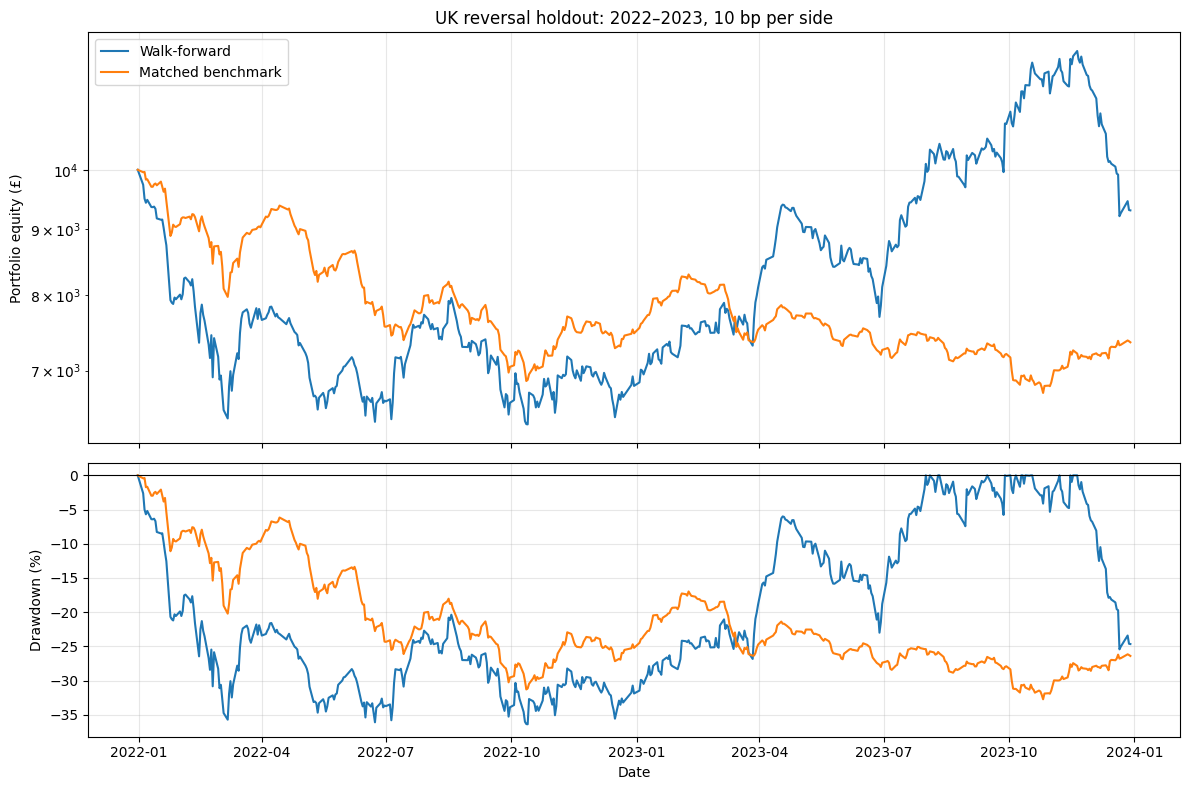

In [60]:
paired_returns = uk_holdout_equity.pct_change(fill_method=None).iloc[1:]
uk_holdout_net_excess = (paired_returns["Walk-forward"] - paired_returns["Matched benchmark"]).to_frame("walk_forward_holdout").rename_axis(columns="configuration_id")

pd.testing.assert_index_equal(uk_holdout_net_excess.index, uk_full_schedule.loc[holdout_start:].index)
if not np.isfinite(uk_holdout_net_excess.to_numpy()).all():
    raise ValueError("Resolve unknown holdout returns before inference.")

uk_holdout_inference = reversal_validation.infer_sweep_means(
    net_returns=uk_holdout_net_excess,
    grid=pd.DataFrame(index=uk_holdout_net_excess.columns), 
    rules=uk_frozen_spec["primary_inference"])

display(uk_holdout_inference[["periods", "mean_bps", "hac_se_bps", "ci_lower_bps", "ci_upper_bps", "p_one_sided"]])
uk_holdout_figure = plotting_reversal_signals.plot_equity_and_drawdown(
    uk_holdout_equity,
    title="UK reversal holdout: 2022–2023, 10 bp per side",
    log_equity=True
)

The results here are not significant compared to the benchmark. From the plots, it seems like our strategy performs worse than the benchmark in bad times, but better than it in good times. This downturn in 2022 was pretty consistent, with ml_trading_signals having a similar dip in performance. This one 'bad' holdout isn't enough to stop us, so we perform another holdout test on the next 2 years.

## **Holdout data test (2024-2025)**

### Data handling

In [61]:
uk_extension_spec = {
    "frozen_strategy": json.loads(freeze_path.read_text()),
    "original_spec_sha256": hashlib.sha256(freeze_path.read_bytes()).hexdigest(),
    "evaluation_start": "2024-01-01",
    "evaluation_end_exclusive": "2026-01-01",
    "initial_state": "cash at final 2023 close",
    "initial_capital_gbp": 10_000,
    "training_history": "expanding from original development start",
    "selection_calendar": "continue original 63-session calendar",
    "download_start": "2023-01-01",  #overlap for data reconciliation
    "download_end_exclusive": "2026-01-01",
    "combined_2022_2025_report": "supplementary"
}

extension_cache_dir = (_REPO_ROOT / "reversal_signals" / "data" / "uk_extension_2023_2025_v1")
extension_cache_dir.mkdir(parents=True, exist_ok=True)

extension_spec_path = extension_cache_dir / "extension_spec.json"
extension_spec_text = json.dumps(uk_extension_spec, indent=2, sort_keys=True) + "\n"
if extension_spec_path.exists():
    if extension_spec_path.read_text() != extension_spec_text:
        raise ValueError("Settings differ from the saved extension.")
else:
    with extension_spec_path.open("x") as file:
        file.write(extension_spec_text)

#preserve original evaluation seperately
for filename, frame in {
    "original_holdout_equity.pkl": uk_holdout_equity,
    "original_holdout_inference.pkl": uk_holdout_inference,
    "original_holdout_choices.pkl": uk_holdout_choices
}.items():
    path = holdout_cache_dir / filename
    if path.exists():
        pd.testing.assert_frame_equal(pd.read_pickle(path), frame)
    else:
        frame.to_pickle(path)

print("Extension fixed: 2024–2025.")
print("Original holdout outputs preserved.")

Extension fixed: 2024–2025.
Original holdout outputs preserved.


In [62]:
extension_download_dir = extension_cache_dir / "ticker_prices"
extension_download_dir.mkdir(exist_ok=True)

extension_tickers = uk_extension_spec["frozen_strategy"]["tickers"]
extension_frames = []
extension_records = []

for number, ticker in enumerate(extension_tickers, start=1):
    path = extension_download_dir / f"{ticker}.pkl"

    try:
        if path.exists():
            prices = pd.read_pickle(path)
            status = "cached"
        else:
            prices = reversal_data.fetch_reversal_data(
                ticker,
                start=uk_extension_spec["download_start"],
                end=uk_extension_spec["download_end_exclusive"]
            )
            temporary_path = path.with_suffix(".pkl.tmp")
            prices.to_pickle(temporary_path)
            temporary_path.replace(path)
            status = "downloaded"

        extension_frames.append(prices.assign(ticker=ticker))
        extension_records.append({
            "ticker": ticker,
            "status": status,
            "rows": len(prices),
            "error": ""
        })

    except Exception as exc:
        extension_records.append({
            "ticker": ticker,
            "status": "failed",
            "rows": 0,
            "error": str(exc)
        })

    if number % 25 == 0 or number == len(extension_tickers):
        print(f"Processed {number}/{len(extension_tickers)}", flush=True)

uk_extension_download_report = pd.DataFrame(extension_records).set_index("ticker")
uk_extension_download_report.to_csv(extension_cache_dir / "download_report.csv")

if not extension_frames:
    raise ValueError("No prices available; inspect the download report.")

uk_extension_raw_panel = pd.concat(extension_frames).sort_index()
uk_extension_raw_panel.to_pickle(extension_cache_dir / "raw_panel_with_2023_overlap.pkl")
display(uk_extension_download_report["status"].value_counts())

$450.L: possibly delisted; no timezone found

1 Failed download:
['450.L']: possibly delisted; no timezone found
$4GBL.L: possibly delisted; no timezone found

1 Failed download:
['4GBL.L']: possibly delisted; no timezone found
$AFRN.L: possibly delisted; no timezone found

1 Failed download:
['AFRN.L']: possibly delisted; no timezone found
$AGFX.L: possibly delisted; no timezone found

1 Failed download:
['AGFX.L']: possibly delisted; no timezone found


Processed 25/646


$APQ.L: possibly delisted; no timezone found

1 Failed download:
['APQ.L']: possibly delisted; no timezone found


Processed 50/646


$BBB.L: possibly delisted; no timezone found

1 Failed download:
['BBB.L']: possibly delisted; no timezone found
$BELL.L: possibly delisted; no timezone found

1 Failed download:
['BELL.L']: possibly delisted; no timezone found
$BIOM.L: possibly delisted; no timezone found

1 Failed download:
['BIOM.L']: possibly delisted; no timezone found
$BION.L: possibly delisted; no timezone found

1 Failed download:
['BION.L']: possibly delisted; no timezone found
$BLVN.L: possibly delisted; no timezone found

1 Failed download:
['BLVN.L']: possibly delisted; no timezone found
$BMK.L: possibly delisted; no timezone found

1 Failed download:
['BMK.L']: possibly delisted; no timezone found
$BMN.L: possibly delisted; no timezone found

1 Failed download:
['BMN.L']: possibly delisted; no timezone found


...

$VRS.L: possibly delisted; no timezone found

1 Failed download:
['VRS.L']: possibly delisted; no timezone found
$WBI.L: possibly delisted; no timezone found

1 Failed download:
['WBI.L']: possibly delisted; no timezone found


Processed 625/646


$WSG.L: possibly delisted; no timezone found

1 Failed download:
['WSG.L']: possibly delisted; no timezone found
$ZYT.L: possibly delisted; no timezone found

1 Failed download:
['ZYT.L']: possibly delisted; no timezone found


Processed 646/646


status
downloaded    570
failed         76
Name: count, dtype: int64

In [63]:
retry_tickers = ["FOX.L", "ORR.L", "SEA.L"]

for ticker in retry_tickers:
    path = extension_download_dir / f"{ticker}.pkl"

    try:
        if path.exists():
            prices = pd.read_pickle(path)
            status = "cached"
        else:
            prices = reversal_data.fetch_reversal_data(
                ticker,
                start=uk_extension_spec["download_start"],
                end=uk_extension_spec["download_end_exclusive"]
            )
            temporary_path = path.with_suffix(".pkl.tmp")
            prices.to_pickle(temporary_path)
            temporary_path.replace(path)
            status = "downloaded"

        uk_extension_download_report.loc[ticker, ["status", "rows", "error"]] = [status, len(prices), ""]
    except Exception as e:
        uk_extension_download_report.loc[ticker, ["status", "rows", "error"]] = ["failed", 0, str(e)]

#rebuild using all cached files
extension_frames = []

for ticker in extension_tickers:
    path = extension_download_dir / f"{ticker}.pkl"
    if path.exists():
        prices = pd.read_pickle(path)
        extension_frames.append(prices.assign(ticker=ticker))

uk_extension_raw_panel = pd.concat(extension_frames).sort_index()
uk_extension_raw_panel.to_pickle(extension_cache_dir / "raw_panel_with_2023_overlap.pkl")
uk_extension_download_report.to_csv(extension_cache_dir / "download_report.csv")

display(uk_extension_download_report.loc[retry_tickers])
display(uk_extension_download_report["status"].value_counts())

,status,rows,error
ticker,,,
FOX.L,downloaded,758,
ORR.L,downloaded,758,
SEA.L,downloaded,758,


status
downloaded    573
failed         73
Name: count, dtype: int64

In [64]:
extension_audit = uk_extension_raw_panel.reset_index().sort_values(["ticker", "Date"]).copy()

extension_audit["previous_close"] = extension_audit.groupby("ticker")["Close"].shift(1)
extension_audit["close_ratio"] = extension_audit["Close"] / extension_audit["previous_close"]

# Broad review flags; corrections require checking the surrounding data.
extension_audit["near_100x_jump"] = (extension_audit["close_ratio"].between(95, 105) | extension_audit["close_ratio"].between(0.0095, 0.0105))
extension_audit["large_price_move"] = (extension_audit["close_ratio"].ge(2) | extension_audit["close_ratio"].le(0.5))
extension_audit["reported_split"] = extension_audit["Stock Splits"].fillna(0).ne(0)

audit_flags = [
    "near_100x_jump",
    "large_price_move",
    "reported_split"
]

in_extension = (extension_audit["Date"].ge(uk_extension_spec["evaluation_start"]) & extension_audit["Date"].lt(uk_extension_spec["evaluation_end_exclusive"]))

uk_extension_event_audit = extension_audit.loc[
    in_extension & extension_audit[audit_flags].any(axis=1),
    [
        "Date", "ticker", "previous_close",
        "Open", "High", "Low", "Close", "Adj Close",
        "close_ratio", "Volume", "Dividends", "Stock Splits",
    ] + audit_flags].copy()

uk_extension_event_audit.to_csv(extension_cache_dir / "price_event_audit.csv", index=False)
display(uk_extension_event_audit[audit_flags].sum().to_frame("flagged_rows"))
display(uk_extension_event_audit.head(15))

,flagged_rows
near_100x_jump,329
large_price_move,424
reported_split,28


,Date,ticker,previous_close,Open,High,Low,Close,Adj Close,close_ratio,Volume,Dividends,Stock Splits,near_100x_jump,large_price_move,reported_split
204987,2024-07-01,80M.L,0.300,0.3400,0.7270,0.330000,0.6500,0.6500,2.166667,851123676,0.0,0.00,False,True,False
374650,2025-09-10,80M.L,0.320,0.3200,0.8000,0.300000,0.6800,0.6800,2.125000,985403970,0.0,0.00,False,True,False
325411,2025-05-08,88E.L,1.575,0.0680,0.0750,0.060000,0.0650,0.0650,0.041270,32545548,0.0,0.04,False,True,True
327319,2025-05-13,88E.L,0.058,1.3250,1.3980,0.850000,1.1000,1.1000,18.965518,5294539,0.0,0.00,False,True,False
146327,2024-01-26,AEG.L,1.700,0.9000,0.9960,0.400000,0.5000,0.5000,0.294118,40000989,0.0,0.00,False,True,False
160868,2024-03-05,AEG.L,0.325,0.5500,1.3800,0.450000,0.9320,0.9320,2.867692,188674968,0.0,0.00,False,True,False
342162,2025-06-20,AEG.L,0.215,0.2150,0.7850,0.200000,0.5500,0.5500,2.558140,21538795,0.0,0.00,False,True,False
358341,2025-07-30,AGI.L,17.500,17.5000,18.7500,16.040001,17.0000,17.0000,0.971429,100409,0.0,0.10,False,False,True
202859,2024-06-25,AMP.L,1.050,1.2000,2.7000,1.100000,2.3000,2.3000,2.190476,76366143,0.0,0.00,False,True,False
360616,2025-08-05,AMP.L,1.900,1.9000,5.0000,1.800000,4.6000,4.6000,2.421053,16004625,0.0,0.00,False,True,False


In [68]:
import yfinance as yf

repair_pilot_dir = extension_cache_dir / "repair_pilot_v1"
repair_pilot_dir.mkdir(exist_ok=True)

repair_settings = {
    "start": uk_extension_spec["download_start"],
    "end": uk_extension_spec["download_end_exclusive"],
    "interval": "1d",
    "auto_adjust": False,
    "actions": True,
    "keepna": True,
    "multi_level_index": False,
    "progress": False,
    "threads": False,
}

repair_tickers = sorted(
    uk_extension_event_audit.loc[
        uk_extension_event_audit["near_100x_jump"]
        | uk_extension_event_audit["reported_split"],
        "ticker",
    ].unique()
)

print(f"Tickers to compare: {len(repair_tickers)}")

pilot_records = []

for number, ticker in enumerate(repair_tickers, start=1):
    print(
        f"Checking {number}/{len(repair_tickers)}: {ticker}",
        flush=True,
    )

    path = repair_pilot_dir / f"{ticker}.pkl"

    if path.exists():
        payload = pd.read_pickle(path)
        if payload["settings"] != repair_settings:
            raise ValueError(f"Cached settings differ for {ticker}.")
    else:
        payload = {
            "settings": repair_settings.copy(),
            "yfinance_version": yf.__version__,
            "downloaded_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        }

        for label, repair in [
            ("raw_now", False),
            ("repair_candidate", True),
        ]:
            prices = yf.download(
                ticker,
                repair=repair,
                **repair_settings,
            )

            if prices is None or prices.empty:
                raise ValueError(f"No {label} data for {ticker}.")

            prices.index = (
                pd.DatetimeIndex(prices.index)
                .tz_localize(None)
                .rename("Date")
            )
            payload[label] = prices.sort_index()

        temporary_path = path.with_suffix(".pkl.tmp")
        pd.to_pickle(payload, temporary_path)
        temporary_path.replace(path)

    candidate = payload["repair_candidate"]
    pilot_records.append({
        "ticker": ticker,
        "raw_rows": len(payload["raw_now"]),
        "candidate_rows": len(candidate),
        "yfinance_flagged_rows": (
            int(candidate["Repaired?"].fillna(False).sum())
            if "Repaired?" in candidate.columns else None
        ),
        "yfinance_version": payload["yfinance_version"],
    })

display(pd.DataFrame(pilot_records).set_index("ticker"))

Tickers to compare: 73
Checking 1/73: 88E.L
Checking 2/73: AGI.L
Checking 3/73: ANGS.L
Checking 4/73: AUTG.L
Checking 5/73: BBSN.L
Checking 6/73: BCE.L
Checking 7/73: BEM.L
Checking 8/73: BMTO.L
Checking 9/73: BOW.L
Checking 10/73: CHL.L
Checking 11/73: CMX.L
Checking 12/73: COPC.L
Checking 13/73: CORO.L
Checking 14/73: CRTX.L
Checking 15/73: CTAI.L
Checking 16/73: CTL.L
Checking 17/73: DISH.L
Checking 18/73: DSG.L
Checking 19/73: EARN.L
Checking 20/73: ELEG.L
Checking 21/73: FADL.L
Checking 22/73: FKE.L
Checking 23/73: GCG.L
Checking 24/73: GGP.L
Checking 25/73: GWMO.L
Checking 26/73: HSM.L
Checking 27/73: HVTA.L
Checking 28/73: ITIM.L
Checking 29/73: KR1.L
Checking 30/73: KRM.L
Checking 31/73: KRPZ.L
Checking 32/73: LND.L
Checking 33/73: LPA.L
Checking 34/73: LSC.L
Checking 35/73: MAI.L
Checking 36/73: MET.L
Checking 37/73: MET1.L
Checking 38/73: MLVN.L
Checking 39/73: NAR.L
Checking 40/73: NBB.L
Checking 41/73: NTVO.L
Checking 42/73: NWT.L
Checking 43/73: PACS.L
Checking 44/73: PALM


1 Failed download:
['VZLA.L']: possibly delisted; no price data found  (1h 2024-09-22 -> 2025-09-10)


Checking 70/73: WNX.L


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Checking 71/73: WSBN.L
Checking 72/73: XLM.L
Checking 73/73: ZED.L


,raw_rows,candidate_rows,yfinance_flagged_rows,yfinance_version
ticker,,,,
88E.L,758,758,3,1.2.0
AGI.L,758,758,0,1.2.0
ANGS.L,758,758,150,1.2.0
AUTG.L,758,758,3,1.2.0
BBSN.L,758,758,606,1.2.0
...,...,...,...,...
VZLA.L,758,758,356,1.2.0
WNX.L,197,197,19,1.2.0
WSBN.L,758,758,0,1.2.0


In [69]:
repair_exceptions = []
repair_price_columns = ["Open", "High", "Low", "Close", "Adj Close"]

for ticker in repair_tickers:
    payload = pd.read_pickle(repair_pilot_dir / f"{ticker}.pkl")
    raw = payload["raw_now"]
    candidate = payload["repair_candidate"]

    pd.testing.assert_index_equal(raw.index, candidate.index)

    prices = candidate[repair_price_columns]
    ratio = candidate["Close"] / candidate["Close"].shift(1)

    new_missing = (prices.isna() & raw[repair_price_columns].notna()).any(axis=1)
    invalid_price = (prices.notna() & ((prices <= 0) | ~np.isfinite(prices))).any(axis=1)

    comparison = pd.DataFrame({
        "ticker": ticker,
        "raw_close_ratio": raw["Close"] / raw["Close"].shift(1),
        "candidate_close_ratio": ratio,
        "new_missing_price": new_missing,
        "invalid_price": invalid_price,
        "Volume": candidate["Volume"],
        "Stock Splits": candidate["Stock Splits"]
    })

    #review red flags only
    needs_review = (ratio.gt(5) | ratio.lt(0.2) | new_missing | invalid_price)

    in_period = (comparison.index >= pd.Timestamp(uk_extension_spec["evaluation_start"])) & (
        comparison.index < pd.Timestamp(uk_extension_spec["evaluation_end_exclusive"]))
    repair_exceptions.append(comparison.loc[in_period & needs_review])

uk_repair_exceptions = pd.concat(repair_exceptions).reset_index().sort_values(["ticker", "Date"])
uk_repair_exceptions.to_csv(extension_cache_dir / "repair_exceptions.csv", index=False)
display(uk_repair_exceptions)

,Date,ticker,raw_close_ratio,candidate_close_ratio,new_missing_price,invalid_price,Volume,Stock Splits
0,2025-12-22,BCE.L,1000.000003,10.000000,False,False,0,0.000
1,2025-12-31,BCE.L,0.001000,0.100000,False,False,0,0.001
2,2024-02-05,FADL.L,0.010035,0.010035,False,False,6000,0.000
3,2024-03-12,KRPZ.L,100.000002,10000.000224,False,False,0,0.000
4,2024-11-11,KRPZ.L,0.010000,0.010000,False,False,0,0.000
5,2024-01-10,MET.L,1.000000,0.001600,False,False,0,0.000
6,2024-01-16,MET.L,199.999990,199.999990,False,False,2706806,0.000
7,2025-03-24,URU.L,0.952381,NaN,True,False,0,25.000


In [70]:
manual_tickers = ["FADL.L", "KRPZ.L", "URU.L"]

uk_manual_repair_candidates = {
    ticker: pd.read_pickle(
        repair_pilot_dir / f"{ticker}.pkl"
    )["repair_candidate"].copy()
    for ticker in manual_tickers
}

for frame in uk_manual_repair_candidates.values():
    frame["manual_price_correction"] = False
    frame.attrs["quote_currency"] = "GBP"

# Factors apply to the cached repair candidates.
unit_patches = pd.DataFrame(
    [
        ("FADL.L", "2023-01-01", "2024-02-05",
         0.01, "2024-02-02", 143.5),
        ("KRPZ.L", "2023-01-01", "2024-03-12",
         100.0, "2024-03-11", 0.00015),
        ("KRPZ.L", "2024-03-12", "2024-11-11",
         0.01, "2024-03-12", 1.5),
    ],
    columns=[
        "ticker", "start", "end_exclusive",
        "factor", "check_date", "expected_close",
    ],
)

for patch in unit_patches.itertuples(index=False):
    frame = uk_manual_repair_candidates[patch.ticker]
    mask = (
        (frame.index >= pd.Timestamp(patch.start))
        & (frame.index < pd.Timestamp(patch.end_exclusive))
    )

    if not np.isclose(
        frame.loc[patch.check_date, "Close"],
        patch.expected_close,
        rtol=1e-6,
        atol=1e-10,
    ):
        raise ValueError(f"Unexpected source prices for {patch.ticker}.")

    if not frame.loc[mask, "Dividends"].eq(0).all():
        raise ValueError("Dividend treatment needs separate review.")

    frame.loc[mask, repair_price_columns] *= patch.factor
    frame.loc[mask, "manual_price_correction"] = True

# Restore the original vendor quote; its history already reflects the split.
uru_date = pd.Timestamp("2025-03-24")
uru_raw = pd.read_pickle(
    repair_pilot_dir / "URU.L.pkl"
)["raw_now"]
uru_candidate = uk_manual_repair_candidates["URU.L"]

assert uru_candidate.loc[uru_date, repair_price_columns].isna().all()
assert np.isclose(uru_raw.loc[uru_date, "Close"], 4.0)

uru_candidate.loc[uru_date, repair_price_columns] = (
    uru_raw.loc[uru_date, repair_price_columns] * 0.01
)
uru_candidate.loc[uru_date, "manual_price_correction"] = True

pd.to_pickle(
    {
        "prices": uk_manual_repair_candidates,
        "unit_patches": unit_patches,
        "restored_vendor_quote": ("URU.L", "2025-03-24"),
    },
    extension_cache_dir / "manual_repair_candidates_v1.pkl",
)

display(pd.Series(
    {
        ticker: int(frame["manual_price_correction"].sum())
        for ticker, frame in uk_manual_repair_candidates.items()
    },
    name="corrected_rows",
).to_frame())

,corrected_rows
FADL.L,208
KRPZ.L,470
URU.L,1


In [71]:
# Reload the previous stage so rerunning this cell is safe.
review_bundle = pd.read_pickle(
    extension_cache_dir / "manual_repair_candidates_v1.pkl"
)
uk_manual_repair_candidates = review_bundle["prices"]

uk_extension_suspensions = pd.DataFrame(
    [
        ("MET.L", "2023-07-03", "2024-01-16"),
        ("BCE.L", "2024-07-01", "2024-10-14"),
        ("BCE.L", "2025-06-27", None),
    ],
    columns=["ticker", "start", "resume"],
)

for column in ["start", "resume"]:
    uk_extension_suspensions[column] = pd.to_datetime(
        uk_extension_suspensions[column]
    )

for ticker in ["MET.L", "BCE.L"]:
    frame = pd.read_pickle(
        repair_pilot_dir / f"{ticker}.pkl"
    )["repair_candidate"].copy()

    frame["manual_price_correction"] = False
    frame.attrs["quote_currency"] = "GBP"
    uk_manual_repair_candidates[ticker] = frame

for frame in uk_manual_repair_candidates.values():
    frame["known_suspended"] = False

for event in uk_extension_suspensions.itertuples(index=False):
    frame = uk_manual_repair_candidates[event.ticker]

    # Suspension start is included; the resumption date is excluded.
    mask = frame.index >= event.start
    if pd.notna(event.resume):
        mask &= frame.index < event.resume

    if frame.loc[mask, "Volume"].fillna(0).ne(0).any():
        raise ValueError(
            f"Unexpected volume during {event.ticker}'s suspension."
        )

    frame.loc[mask, "known_suspended"] = True
    frame.loc[mask, repair_price_columns] = np.nan

review_bundle["suspensions"] = uk_extension_suspensions

pd.to_pickle(
    review_bundle,
    extension_cache_dir / "manual_repair_candidates_v2.pkl",
)

display(pd.Series(
    {
        ticker: int(
            uk_manual_repair_candidates[ticker]["known_suspended"].sum()
        )
        for ticker in ["MET.L", "BCE.L"]
    },
    name="suspended_rows",
).to_frame())


,suspended_rows
MET.L,137
BCE.L,205


In [72]:
uk_extension_available_tickers = sorted(
    uk_extension_raw_panel["ticker"].unique()
)
uk_extension_new_tickers = sorted(
    set(uk_extension_available_tickers) - set(uk_full_gbp_scale.index)
)

metadata_path = extension_cache_dir / "additional_quote_metadata.pkl"

if metadata_path.exists():
    uk_extension_quote_metadata = pd.read_pickle(metadata_path)
else:
    uk_extension_quote_metadata = reversal_data.fetch_quote_snapshot(
        uk_extension_new_tickers
    )
    uk_extension_quote_metadata.to_pickle(metadata_path)

uk_extension_quote_metadata = uk_extension_quote_metadata.reindex(
    uk_extension_new_tickers
)

# These factors apply to the original, unrepaired price downloads.
uk_extension_additional_scales = (
    uk_extension_quote_metadata["currency"]
    .map({"GBp": 0.01, "GBX": 0.01, "GBP": 1.0})
    .rename("gbp_per_price_unit")
)

unresolved = (
    uk_extension_quote_metadata["fetch_status"].ne("ok")
    | uk_extension_additional_scales.isna()
)

if unresolved.any():
    display(
        uk_extension_quote_metadata.loc[
            unresolved, ["currency", "fetch_status", "error"]
        ]
    )
    raise ValueError("Resolve these quote currencies before continuing.")

uk_extension_raw_gbp_scale = pd.concat(
    [uk_full_gbp_scale, uk_extension_additional_scales]
).reindex(uk_extension_available_tickers)

assert uk_extension_raw_gbp_scale.index.is_unique
assert uk_extension_raw_gbp_scale.notna().all()

print("Additional tickers checked:", len(uk_extension_new_tickers))
print("Downloaded tickers with conversion factors:",
      len(uk_extension_raw_gbp_scale))

display(
    uk_extension_quote_metadata["currency"]
    .value_counts()
    .rename("additional_tickers")
    .to_frame()
)


Additional tickers checked: 27
Downloaded tickers with conversion factors: 573


,additional_tickers
currency,
GBp,27


In [73]:
review_bundle = pd.read_pickle(
    extension_cache_dir / "manual_repair_candidates_v2.pkl"
)

money_columns = repair_price_columns + ["Dividends"]
data_columns = money_columns + ["Volume", "Stock Splits"]
flag_columns = [
    "known_suspended", "manual_price_correction", "Repaired?"
]

uk_extension_candidate_gbp = (
    uk_extension_raw_panel
    .set_index("ticker", append=True)
    .sort_index()
    .copy()
)

assert uk_extension_candidate_gbp.index.is_unique

uk_extension_candidate_gbp[data_columns] = (
    uk_extension_candidate_gbp[data_columns].astype(float)
)
uk_extension_candidate_gbp[money_columns] = (
    uk_extension_candidate_gbp[money_columns].mul(
        uk_extension_candidate_gbp.index
        .get_level_values("ticker")
        .map(uk_extension_raw_gbp_scale),
        axis=0,
    )
)

uk_extension_candidate_gbp["price_source"] = "original_download"
uk_extension_candidate_gbp[flag_columns] = False

for ticker in repair_tickers:
    if ticker in review_bundle["prices"]:
        frame = review_bundle["prices"][ticker].copy()
        source = "manual_review"
    else:
        frame = pd.read_pickle(
            repair_pilot_dir / f"{ticker}.pkl"
        )["repair_candidate"].copy()
        source = "yfinance_repair"

    # These candidates are already in GBP.
    replacement = frame.assign(ticker=ticker).set_index(
        "ticker", append=True
    )

    if not replacement.index.isin(
        uk_extension_candidate_gbp.index
    ).all():
        raise ValueError(f"Unexpected replacement dates for {ticker}.")

    uk_extension_candidate_gbp.loc[
        replacement.index, data_columns
    ] = replacement[data_columns].to_numpy(dtype=float)

    uk_extension_candidate_gbp.loc[
        replacement.index, "price_source"
    ] = source

    for column in flag_columns:
        if column in replacement:
            uk_extension_candidate_gbp.loc[
                replacement.index, column
            ] = replacement[column].fillna(False).to_numpy(dtype=bool)

uk_extension_candidate_gbp.attrs["quote_currency"] = "GBP"
uk_extension_candidate_gbp.to_pickle(
    extension_cache_dir / "candidate_panel_gbp_v1.pkl"
)

display(
    uk_extension_candidate_gbp.reset_index()
    .groupby("price_source")["ticker"]
    .nunique()
    .rename("tickers")
    .to_frame()
)

,tickers
price_source,
manual_review,5
original_download,500
yfinance_repair,68


In [74]:
uk_extension_reconciled_gbp = pd.read_pickle(
    extension_cache_dir / "candidate_panel_gbp_v1.pkl"
)

money_columns = repair_price_columns + ["Dividends"]
dates = uk_extension_reconciled_gbp.index.get_level_values("Date")
tickers = uk_extension_reconciled_gbp.index.get_level_values("ticker")

# Apply the same FORG correction used in the original holdout.
forg_event = (pd.Timestamp("2023-12-21"), "FORG.L")

np.testing.assert_allclose(
    uk_extension_reconciled_gbp.loc[
        forg_event, ["Close", "Stock Splits"]
    ].to_numpy(dtype=float),
    [0.03, 0.1],
    rtol=1e-6,
)

forg_after = (
    (tickers == "FORG.L")
    & (dates >= forg_event[0])
)

uk_extension_reconciled_gbp.loc[forg_after, money_columns] *= 0.1
uk_extension_reconciled_gbp.loc[forg_after, "Volume"] /= 0.1
uk_extension_reconciled_gbp.loc[forg_event, "Stock Splits"] = 0.01
uk_extension_reconciled_gbp.loc[
    forg_after, "manual_price_correction"
] = True
uk_extension_reconciled_gbp.loc[
    forg_after, "price_source"
] = "manual_review"

# These four differences are constant adjusted-close rebases.
uk_extension_reconciled_gbp["adj_close_rebase_factor"] = 1.0
rebase_records = []

for ticker in ["ARS.L", "BBSN.L", "FKE.L", "LPA.L"]:
    reference = uk_full_clean_panel.loc[
        uk_full_clean_panel["ticker"].eq(ticker),
        money_columns + ["Volume", "Stock Splits"],
    ].loc["2023-01-01":"2023-12-31"].copy()

    reference[money_columns] *= uk_full_gbp_scale.loc[ticker]

    candidate = uk_extension_reconciled_gbp.xs(
        ticker, level="ticker"
    ).loc[reference.index]

    # Confirm that this is not a change to prices, cash events or volume.
    unchanged_columns = [
        "Open", "High", "Low", "Close",
        "Dividends", "Volume", "Stock Splits",
    ]
    np.testing.assert_allclose(
        candidate[unchanged_columns],
        reference[unchanged_columns],
        rtol=1e-5,
        atol=1e-8,
        equal_nan=True,
    )
    pd.testing.assert_series_equal(
        candidate["Adj Close"].isna(),
        reference["Adj Close"].isna(),
    )

    ratios = (
        reference["Adj Close"] / candidate["Adj Close"]
    ).dropna()

    if ratios.empty or not np.isfinite(ratios).all():
        raise ValueError(f"Invalid overlap ratios for {ticker}.")

    factor = ratios.median()
    np.testing.assert_allclose(
        ratios / factor, 1.0, rtol=1e-5, atol=1e-8
    )

    affected = tickers == ticker
    uk_extension_reconciled_gbp.loc[
        affected, "Adj Close"
    ] *= factor
    uk_extension_reconciled_gbp.loc[
        affected, "adj_close_rebase_factor"
    ] = factor

    rebase_records.append({
        "ticker": ticker,
        "factor": factor,
        "overlap_rows": len(ratios),
    })

uk_extension_rebases = pd.DataFrame(
    rebase_records
).set_index("ticker")

uk_extension_reconciled_gbp.to_pickle(
    extension_cache_dir / "candidate_panel_gbp_v2.pkl"
)
uk_extension_rebases.to_pickle(
    extension_cache_dir / "overlap_adjustment_rebases_v1.pkl"
)

print("FORG rows corrected:", int(forg_after.sum()))
display(uk_extension_rebases.round(6))

FORG rows corrected: 512


,factor,overlap_rows
ticker,,
ARS.L,1.012865,251
BBSN.L,1.007826,251
FKE.L,1.031254,251
LPA.L,1.012941,251


In [75]:
money_columns = repair_price_columns + ["Dividends"]
data_columns = money_columns + ["Volume", "Stock Splits"]

# Separate working copy of the historical inputs.
uk_history_gbp = (
    uk_full_clean_panel
    .set_index("ticker", append=True)[data_columns]
    .sort_index()
    .copy()
)
uk_history_gbp[money_columns] = uk_history_gbp[money_columns].mul(
    uk_history_gbp.index.get_level_values("ticker").map(
        uk_full_gbp_scale
    ),
    axis=0,
)
uk_history_gbp["known_suspended"] = uk_full_market["known_suspended"]

common = uk_history_gbp.index.intersection(
    uk_extension_reconciled_gbp.index
)
before = uk_history_gbp.loc[common]
after = uk_extension_reconciled_gbp.loc[common]

audit = {}

for column, label in [
    ("Close", "close"),
    ("Adj Close", "adjusted"),
    ("Volume", "volume"),
]:
    ratio = (after[column] / before[column]).where(
        before[column].gt(0) & after[column].gt(0)
    )
    factor = ratio.groupby(level="ticker").median()
    relative = ratio / ratio.index.get_level_values("ticker").map(
        factor
    )

    audit[f"{label}_factor"] = factor
    audit[f"{label}_varying_rows"] = (
        ratio.notna()
        & ~np.isclose(relative, 1.0, rtol=1e-5, atol=1e-8)
    ).groupby(level="ticker").sum()

audit["new_missing_close"] = (
    before["Close"].notna() & after["Close"].isna()
).groupby(level="ticker").sum()

audit["changed_dividends"] = pd.Series(
    ~np.isclose(
        before["Dividends"],
        after["Dividends"],
        rtol=1e-5,
        atol=1e-8,
        equal_nan=True,
    ),
    index=common,
).groupby(level="ticker").sum()

uk_overlap_audit = pd.DataFrame(audit)
factor_columns = ["close_factor", "adjusted_factor", "volume_factor"]

uk_overlap_audit["needs_review"] = (
    (~np.isclose(
        uk_overlap_audit[factor_columns],
        1.0,
        rtol=1e-5,
        atol=1e-8,
    )).any(axis=1)
    | uk_overlap_audit.drop(columns=factor_columns).gt(0).any(axis=1)
)

uk_history_gbp.to_pickle(
    extension_cache_dir / "historical_input_gbp_v1.pkl"
)
uk_overlap_audit.to_pickle(
    extension_cache_dir / "overlap_audit_v1.pkl"
)

print("Tickers compared:", len(uk_overlap_audit))
print("Flagged:", int(uk_overlap_audit["needs_review"].sum()))
display(
    uk_overlap_audit.loc[uk_overlap_audit["needs_review"]].round(6)
)

Tickers compared: 546
Flagged: 27


,close_factor,close_varying_rows,adjusted_factor,adjusted_varying_rows,volume_factor,volume_varying_rows,new_missing_close,changed_dividends,needs_review
ticker,,,,,,,,,
BMTO.L,1.0,0,0.982580,153,1.0,0,0,0,True
CHL.L,100.0,0,100.000000,0,1.0,0,0,0,True
CMCL.L,1.0,0,1.000000,0,1.0,0,0,4,True
CMX.L,1.0,0,0.788889,47,1.0,0,0,0,True
CRE.L,1.0,0,1.000000,0,1.0,0,0,1,True
CRTX.L,1.0,0,1.000000,102,1.0,0,0,0,True
DISH.L,100.0,0,100.000000,0,1.0,0,0,0,True
ELEG.L,100.0,0,100.000000,0,1.0,0,0,0,True
GCG.L,100.0,0,100.000000,0,1.0,0,0,0,True


### Actual test

## **Risk Management**